In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd #alias

file_path = '/content/drive/My Drive/Ashton/waterpolo_with_rating_01232025.csv'
data = pd.read_csv(file_path, dtype={'Zip Code': str}, encoding='ISO-8859-1')
print(data.head())

   ranking                                   name State  Wins  Losses  Draw  \
0        1  JSerra Catholic (San Juan Capistrano)    CA    29       4     0   
1        2         Newport Harbor (Newport Beach)    CA    33       1     0   
2        3         Cathedral Catholic (San Diego)    CA    23       7     0   
3        4           Sacred Heart Prep (Atherton)    CA    19      10     0   
4        5              Clear Creek (League City)    TX    32       0     1   

   strength_of_schedule Public/Private Section/Region  \
0                 34.20        Private       Southern   
1                 49.75         Public       Southern   
2                 33.40        Private      San Diego   
3                 32.90        Private  Central Coast   
4                 17.00         Public          South   

                     Address  ...     Varsity Boys' Coach Email  \
0  26351 Junipero Serra Road  ...             dclute@jserra.org   
1          600 Irvine Avenue  ...         rsincl

In [ ]:
## Winning rate variable creation
data['Total Games'] = data['Wins'] + data['Losses'] + data['Draw']

# Winning rate 계산 (Wins / Total Games)
data['Winning_Rate'] = data['Wins'] / data['Total Games']

print(data[['Wins', 'Losses', 'Draw', 'Total Games', 'Winning_Rate']].head())

data['Total Games'] = data['Wins'] + data['Losses'] + data['Draw']

data['Winning_Rate'] = data['Wins'] / data['Total Games'].replace(0, pd.NA)

print(data[['Wins', 'Losses', 'Draw', 'Total Games', 'Winning_Rate']].head())

data['Winning_Rate'] = data['Winning_Rate'].fillna(0)

   Wins  Losses  Draw  Total Games  Winning_Rate
0    29       4     0           33      0.878788
1    33       1     0           34      0.970588
2    23       7     0           30      0.766667
3    19      10     0           29      0.655172
4    32       0     1           33      0.969697
   Wins  Losses  Draw  Total Games  Winning_Rate
0    29       4     0           33      0.878788
1    33       1     0           34      0.970588
2    23       7     0           30      0.766667
3    19      10     0           29      0.655172
4    32       0     1           33      0.969697


In [ ]:
print(data['Zip Code'].head())

0    92675
1    92663
2    92130
3    94027
4    77546
Name: Zip Code, dtype: object


In [ ]:
summary = data.describe() #descriptive statstics

In [ ]:
print(summary)

          ranking        Wins      Losses        Draw  strength_of_schedule  \
count  755.000000  755.000000  755.000000  755.000000            755.000000   
mean   378.981457   10.917881   10.674172    0.039735              2.409020   
std    218.125599    6.918137    4.117931    0.406851             18.536347   
min      1.000000    0.000000    0.000000    0.000000            -26.140000   
25%    190.500000    5.000000    8.000000    0.000000             -6.600000   
50%    379.000000   11.000000   11.000000    0.000000              1.500000   
75%    567.500000   16.000000   13.000000    0.000000              9.250000   
max    756.000000   33.000000   25.000000   10.000000            408.000000   

        longitude    latitude        .1  Total Games  Winning_Rate  
count  755.000000  755.000000  0.0  0.0   755.000000    755.000000  
mean  -114.904621   34.900532  NaN  NaN    21.631788      0.464313  
std     10.108048    3.650078  NaN  NaN     7.003754      0.225683  
min   -157.8

In [ ]:
print(data.columns.tolist())

['ranking', 'name', 'State', 'Wins', 'Losses', 'Draw', 'strength_of_schedule', 'Public/Private', 'Section/Region', 'Address', 'City', 'Zip Code', 'longitude', 'latitude', 'School Phone', 'Athletic Director', 'AD Email', 'AD Phone', "Boys' Level", "Boys' Season", "Varsity Boys' Coach", "Varsity Boys' Coach Email", "Varsity Boys' Coach Phone", "Girls' Level", "Girls' Season", "Varsity Girls' Coach", "Varsity Girls' Coach Email", "Varsity Girls' Coach Phone", 'Density', ' ', ' .1', 'Total Games', 'Winning_Rate']


In [ ]:
data['Density'] = pd.to_numeric(data['Density'], errors='coerce')

In [ ]:
print(data.columns.tolist())

['ranking', 'name', 'State', 'Wins', 'Losses', 'Draw', 'strength_of_schedule', 'Public/Private', 'Section/Region', 'Address', 'City', 'Zip Code', 'longitude', 'latitude', 'School Phone', 'Athletic Director', 'AD Email', 'AD Phone', "Boys' Level", "Boys' Season", "Varsity Boys' Coach", "Varsity Boys' Coach Email", "Varsity Boys' Coach Phone", "Girls' Level", "Girls' Season", "Varsity Girls' Coach", "Varsity Girls' Coach Email", "Varsity Girls' Coach Phone", 'Density', ' ', ' .1', 'Total Games', 'Winning_Rate']


In [ ]:
import os
import numpy as np
import pandas as pd
from libpysal.weights import KNN
from esda.moran import Moran

# ------------------------------------------------------------
# 1. Clean column names and numeric columns
# ------------------------------------------------------------

# Remove accidentally blank columns
data = data.loc[:, ~data.columns.str.strip().isin(["", ".1"])].copy()

# Convert needed columns to numeric
numeric_cols = ["Wins", "Losses", "Draw", "Total Games", "Winning_Rate",
                "latitude", "longitude", "Density"]

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# ------------------------------------------------------------
# 2. Create ranking
# ------------------------------------------------------------

# If Winning_Rate already exists, use it.
# If it is missing or has many missing values, recompute it.
if "Winning_Rate" not in data.columns or data["Winning_Rate"].isna().all():
    data["Total Games"] = data["Wins"] + data["Losses"] + data["Draw"]
    data["Winning_Rate"] = (data["Wins"] + 0.5 * data["Draw"]) / data["Total Games"]

# Highest winning rate gets rank 1.
# method="average" allows ties like 13.5.
data["Winning_Rate_Rank"] = data["Winning_Rate"].rank(
    ascending=False,
    method="average"
)

# Reverse the winning-rate rank so that higher values mean stronger performance.
data["Reversed_Ranking"] = (
    data["Winning_Rate_Rank"].max() + 1 - data["Winning_Rate_Rank"]
)

# Check the new DV
print("DV check:")
display(
    data[["ranking", "name", "Wins", "Losses", "Draw", "Total Games",
          "Winning_Rate", "Winning_Rate_Rank", "Reversed_Ranking"]]
    .sort_values("Winning_Rate_Rank")
    .head(20)
)

# ------------------------------------------------------------
# 3. Prepare clean dataframe for Moran's I
# ------------------------------------------------------------

y_col = "Reversed_Ranking"

df = data.dropna(subset=["latitude", "longitude", y_col]).copy()

print("\nSample size check:")
print("National N:", len(df))
print("California N:", len(df[df["State"] == "CA"]))

# ------------------------------------------------------------
# 4. Function for Moran's I
# ------------------------------------------------------------

def run_global_moran(dataset, region_name, k=8):
    coords = list(zip(dataset["longitude"].values, dataset["latitude"].values))
    y = dataset[y_col].values

    w = KNN.from_array(coords, k=k)
    w.transform = "r"

    np.random.seed(12345)
    moran = Moran(y, w, permutations=999)

    return {
        "Region": region_name,
        "k": k,
        "N_teams": len(dataset),
        "Global_Morans_I": moran.I,
        "Permutation_p_value": moran.p_sim
    }

# ------------------------------------------------------------
# 5. Main k = 8 Moran's I
# ------------------------------------------------------------

main_results = []

main_results.append(run_global_moran(df, "National", k=8))

ca_df = df[df["State"] == "CA"].copy()
main_results.append(run_global_moran(ca_df, "California", k=8))

main_table = pd.DataFrame(main_results)
main_table_display = main_table.copy()
main_table_display["Global_Morans_I"] = main_table_display["Global_Morans_I"].round(3)
main_table_display["Permutation_p_value"] = main_table_display["Permutation_p_value"].round(3)

print("\nMain Moran's I results, k = 8:")
display(main_table_display)

# ------------------------------------------------------------
# 6. k sensitivity check
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

k_values = [4, 6, 8, 10, 12]
sensitivity_results = []

for k in k_values:
    sensitivity_results.append(run_global_moran(df, "National", k=k))
    sensitivity_results.append(run_global_moran(ca_df, "California", k=k))

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table_display = sensitivity_table.copy()
sensitivity_table_display["Global_Morans_I"] = sensitivity_table_display["Global_Morans_I"].round(3)
sensitivity_table_display["Permutation_p_value"] = sensitivity_table_display["Permutation_p_value"].round(3)

print("\nk sensitivity check:")
display(sensitivity_table_display)

# Save results
sensitivity_table_display.to_csv(
    "results/sensitivity_k_values_morans_i.csv",
    index=False
)

# ------------------------------------------------------------
# 7. Confirm k = 8 rows
# ------------------------------------------------------------

print("\nCheck k = 8 rows:")
display(sensitivity_table_display[sensitivity_table_display["k"] == 8])

DV check:


,ranking,name,Wins,Losses,Draw,Total Games,Winning_Rate,Winning_Rate_Rank,Reversed_Ranking
83,85,Brunswick School (Greenwich),14,0,0,14,1.000000,1.0,737.5
1,2,Newport Harbor (Newport Beach),33,1,0,34,0.970588,2.0,736.5
4,5,Clear Creek (League City),32,0,1,33,0.969697,3.0,735.5
331,333,Bret Harte (Angels Camp),23,1,0,24,0.958333,4.5,734.0
7,8,Marcus (Flower Mound),23,1,0,24,0.958333,4.5,734.0
258,260,Pharr-San Juan-Alamo North (Pharr),16,1,0,17,0.941176,6.0,732.5
59,61,Arcadia,25,2,0,27,0.925926,7.0,731.5
88,90,Alvin,18,2,0,20,0.900000,8.5,730.0
47,49,Alamo Heights (San Antonio),18,2,0,20,0.900000,8.5,730.0
105,107,Liberal Arts & Science Academy - Austin (Austin),17,1,1,19,0.894737,10.0,728.5



Sample size check:
National N: 755
California N: 571

Main Moran's I results, k = 8:


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,Region,k,N_teams,Global_Morans_I,Permutation_p_value
0,National,8,755,-0.05,0.003
1,California,8,571,-0.04,0.014


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix i


k sensitivity check:


,Region,k,N_teams,Global_Morans_I,Permutation_p_value
0,National,4,755,-0.041,0.035
1,California,4,571,-0.023,0.219
2,National,6,755,-0.045,0.014
3,California,6,571,-0.030,0.097
4,National,8,755,-0.050,0.003
5,California,8,571,-0.040,0.014
6,National,10,755,-0.041,0.004
7,California,10,571,-0.034,0.023
8,National,12,755,-0.041,0.002
9,California,12,571,-0.038,0.003



Check k = 8 rows:


,Region,k,N_teams,Global_Morans_I,Permutation_p_value
4,National,8,755,-0.05,0.003
5,California,8,571,-0.04,0.014


In [ ]:
# Competitive proximity (Density)
prox_stats = data['Density'].agg(['min', 'max', 'mean', 'std'])
print("Competitive Proximity (Density):")
print(prox_stats)

# End-of-season performance (Reversed_Ranking)
perf_stats = data['Reversed_Ranking'].agg(['min', 'max', 'mean', 'std'])
print("\nEnd-of-Season Performance (Reversed Ranking):")
print(perf_stats)

Competitive Proximity (Density):
min     0.000000
max     0.150000
mean    0.043020
std     0.037925
Name: Density, dtype: float64

End-of-Season Performance (Reversed Ranking):
min       1.000000
max     737.500000
mean    360.500000
std     218.064589
Name: Reversed_Ranking, dtype: float64


In [ ]:
from scipy.stats import spearmanr

# Spearman rank correlation
rho, pval = spearmanr(
    data['Density'],
    data['Reversed_Ranking']
)

print("Spearman correlation (ρ):", rho)
print("p-value:", pval)

Spearman correlation (ρ): nan
p-value: nan


In [ ]:
print(data[['Density', 'Reversed_Ranking']].isna().sum())

print(np.isinf(data['Density']).sum())
print(np.isinf(data['Reversed_Ranking']).sum())

Density             3
Reversed_Ranking    0
dtype: int64
0
0


In [ ]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import ttest_ind

# 필요한 두 컬럼만 복사
df = data[['Density', 'Reversed_Ranking']].copy()

# inf, -inf를 NaN으로 바꾸고 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# -----------------------------
# 1) Linear regression (OLS)
# -----------------------------
X = sm.add_constant(df['Density'])
y = df['Reversed_Ranking']

model_perf = sm.OLS(y, X).fit()

beta = model_perf.params['Density']
r2   = model_perf.rsquared
pval = model_perf.pvalues['Density']

print("OLS: Reversed_Ranking ~ Density")
print(f"β (Density) = {beta:.6f}")
print(f"R² = {r2:.6f}")
print(f"p = {pval:.6g}")

# -----------------------------
# 2) High vs Low proximity groups
# -----------------------------
q25 = df['Density'].quantile(0.25)
q75 = df['Density'].quantile(0.75)

low_group  = df.loc[df['Density'] <= q25, 'Reversed_Ranking']
high_group = df.loc[df['Density'] >= q75, 'Reversed_Ranking']

mean_high = high_group.mean()
sd_high   = high_group.std(ddof=1)
mean_low  = low_group.mean()
sd_low    = low_group.std(ddof=1)

t_stat, p_group = ttest_ind(high_group, low_group, equal_var=False)

print("\nHigh vs Low proximity (top/bottom quartile of Density)")
print(f"High group n = {len(high_group)}, mean ± SD = {mean_high:.3f} ± {sd_high:.3f}")
print(f"Low  group n = {len(low_group)}, mean ± SD = {mean_low:.3f} ± {sd_low:.3f}")
print(f"Group comparison p = {p_group:.6g}")

OLS: Reversed_Ranking ~ Density
β (Density) = 91.950739
R² = 0.000255
p = 0.661672

High vs Low proximity (top/bottom quartile of Density)
High group n = 202, mean ± SD = 370.285 ± 203.673
Low  group n = 195, mean ± SD = 343.236 ± 229.024
Group comparison p = 0.215013


In [ ]:
!pip -q install libpysal esda splot geopandas

In [ ]:
import numpy as np
import pandas as pd

# ---- choose outcome variable ----
y_col = 'Reversed_Ranking'   # or 'Winning_Rate'

# ---- clean & subset ----
needed = ['latitude', 'longitude', y_col]
df = data.copy()

# numeric conversion (in case strings)
for c in ['latitude', 'longitude', y_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=needed).copy()

print("Rows used:", len(df))
print(df[needed].head())

Rows used: 755
    latitude   longitude  Reversed_Ranking
0  33.520979 -117.667821             725.0
1  33.623604 -117.910973             736.5
2  32.959655 -117.201469             676.5
3  37.448149 -122.194356             580.5
4  29.550575  -95.187588             735.5


In [ ]:
from libpysal.weights import KNN
from esda.moran import Moran

coords = list(zip(df['longitude'].values, df['latitude'].values))

k = 8
w = KNN.from_array(coords, k=k)
w.transform = 'r'  # row-standardize

y = df[y_col].values

mi = Moran(y, w, permutations=999)

print(f"Outcome: {y_col}")
print(f"k = {k}")
print("Global Moran's I:", mi.I)
print("Expected I:", mi.EI)
print("z-score:", mi.z_norm)
print("p-value (normal approx):", mi.p_norm)
print("p-value (permutation):", mi.p_sim)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Outcome: Reversed_Ranking
k = 8
Global Moran's I: -0.05047395248537956
Expected I: -0.001326259946949602
z-score: -2.8897190656592007
p-value (normal approx): 0.003855862443484271
p-value (permutation): 0.001


In [ ]:
from libpysal.weights import KNN
from esda.moran import Moran
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# k sensitivity check using the same DV as the main analysis
# ------------------------------------------------------------

# Make sure df and y_col already exist
print("Outcome variable:", y_col)
print("N in df:", len(df))
print("Columns in df:", df.columns.tolist())

# Coordinates and outcome
coords = list(zip(df['longitude'].values, df['latitude'].values))
y = df[y_col].values

k_values = [4, 6, 8, 10, 12]
sensitivity_results = []

for k in k_values:
    w = KNN.from_array(coords, k=k)
    w.transform = 'r'  # row-standardize

    np.random.seed(12345)
    mi = Moran(y, w, permutations=999)

    sensitivity_results.append({
        "Region": "National",
        "Outcome": y_col,
        "k": k,
        "N": len(df),
        "Global_Morans_I": mi.I,
        "Expected_I": mi.EI,
        "z_score": mi.z_norm,
        "p_value_normal": mi.p_norm,
        "p_value_permutation": mi.p_sim
    })

# Make results table
sensitivity_table = pd.DataFrame(sensitivity_results)

# Rounded display version
sensitivity_table_display = sensitivity_table.copy()
sensitivity_table_display["Global_Morans_I"] = sensitivity_table_display["Global_Morans_I"].round(3)
sensitivity_table_display["Expected_I"] = sensitivity_table_display["Expected_I"].round(3)
sensitivity_table_display["z_score"] = sensitivity_table_display["z_score"].round(3)
sensitivity_table_display["p_value_normal"] = sensitivity_table_display["p_value_normal"].round(3)
sensitivity_table_display["p_value_permutation"] = sensitivity_table_display["p_value_permutation"].round(3)

print("\nNational k sensitivity check:")
print(sensitivity_table_display.to_string(index=False))

display(sensitivity_table_display)

# Save results
os.makedirs("results", exist_ok=True)
sensitivity_table_display.to_csv("results/sensitivity_k_values_morans_i_national.csv", index=False)

# Check k = 8 specifically
print("\nCheck k = 8 result:")
print(sensitivity_table_display[sensitivity_table_display["k"] == 8].to_string(index=False))

Outcome variable: Reversed_Ranking
N in df: 755
Columns in df: ['ranking', 'name', 'State', 'Wins', 'Losses', 'Draw', 'strength_of_schedule', 'Public/Private', 'Section/Region', 'Address', 'City', 'Zip Code', 'longitude', 'latitude', 'School Phone', 'Athletic Director', 'AD Email', 'AD Phone', "Boys' Level", "Boys' Season", "Varsity Boys' Coach", "Varsity Boys' Coach Email", "Varsity Boys' Coach Phone", "Girls' Level", "Girls' Season", "Varsity Girls' Coach", "Varsity Girls' Coach Email", "Varsity Girls' Coach Phone", 'Density', 'Total Games', 'Winning_Rate', 'Winning_Rate_Rank', 'Reversed_Ranking']


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)



National k sensitivity check:
  Region          Outcome  k   N  Global_Morans_I  Expected_I  z_score  p_value_normal  p_value_permutation
National Reversed_Ranking  4 755           -0.041      -0.001   -1.642           0.101                0.035
National Reversed_Ranking  6 755           -0.045      -0.001   -2.209           0.027                0.014
National Reversed_Ranking  8 755           -0.050      -0.001   -2.890           0.004                0.003
National Reversed_Ranking 10 755           -0.041      -0.001   -2.634           0.008                0.004
National Reversed_Ranking 12 755           -0.041      -0.001   -2.852           0.004                0.002


,Region,Outcome,k,N,Global_Morans_I,Expected_I,z_score,p_value_normal,p_value_permutation
0,National,Reversed_Ranking,4,755,-0.041,-0.001,-1.642,0.101,0.035
1,National,Reversed_Ranking,6,755,-0.045,-0.001,-2.209,0.027,0.014
2,National,Reversed_Ranking,8,755,-0.050,-0.001,-2.890,0.004,0.003
3,National,Reversed_Ranking,10,755,-0.041,-0.001,-2.634,0.008,0.004
4,National,Reversed_Ranking,12,755,-0.041,-0.001,-2.852,0.004,0.002



Check k = 8 result:
  Region          Outcome  k   N  Global_Morans_I  Expected_I  z_score  p_value_normal  p_value_permutation
National Reversed_Ranking  8 755            -0.05      -0.001    -2.89           0.004                0.003


In [ ]:
from esda.moran import Moran_Local

lisa = Moran_Local(y, w, permutations=999)

df['local_I'] = lisa.Is
df['local_p'] = lisa.p_sim
df['cluster'] = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL (PySAL convention)

print(df[['name', y_col, 'local_I', 'local_p', 'cluster']].head(10))

                                    name  Reversed_Ranking   local_I  local_p  \
0  JSerra Catholic (San Juan Capistrano)             725.0  0.133503    0.380   
1         Newport Harbor (Newport Beach)             736.5 -0.606211    0.121   
2         Cathedral Catholic (San Diego)             676.5  0.119893    0.374   
3           Sacred Heart Prep (Atherton)             580.5 -0.069012    0.421   
4              Clear Creek (League City)             735.5 -0.092004    0.445   
5         Corona del Mar (Newport Beach)             688.5 -0.179052    0.354   
6                Menlo School (Atherton)             592.5 -0.077655    0.411   
7                  Marcus (Flower Mound)             734.0  0.873817    0.035   
8         Harvard-Westlake (Studio City)             518.5 -0.002907    0.499   
9                  Mater Dei (Santa Ana)             629.5 -0.420971    0.129   

   cluster  
0        1  
1        4  
2        1  
3        4  
4        4  
5        4  
6        4  
7   

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['longitude'], df['latitude'])],
    crs="EPSG:4326"
)

# 보기 쉽게: 유의한 점만
sig = gdf[gdf['local_p'] < 0.05].copy()
print("Significant local clusters (p<0.05):", len(sig))

# cluster labels
cluster_map = {1:"HH", 2:"LH", 3:"LL", 4:"HL"}
sig['cluster_label'] = sig['cluster'].map(cluster_map)

sig[['name', y_col, 'cluster_label', 'local_p']].head(20)

Significant local clusters (p<0.05): 37


,name,Reversed_Ranking,cluster_label,local_p
7,Marcus (Flower Mound),734.0,HH,0.035
16,Bishop's (La Jolla),452.5,HH,0.013
20,La Jolla,659.0,HH,0.030
30,Boerne-Champion (Boerne),707.0,HL,0.034
34,College Park (Pleasant Hill),679.0,HH,0.047
43,Ripon,708.5,HL,0.036
53,Laguna Beach,419.5,HH,0.046
76,Clovis East (Clovis),529.0,HH,0.025
80,Clovis North (Fresno),529.0,HH,0.023
93,Flower Mound,432.5,HH,0.013


<Figure size 800x600 with 0 Axes>

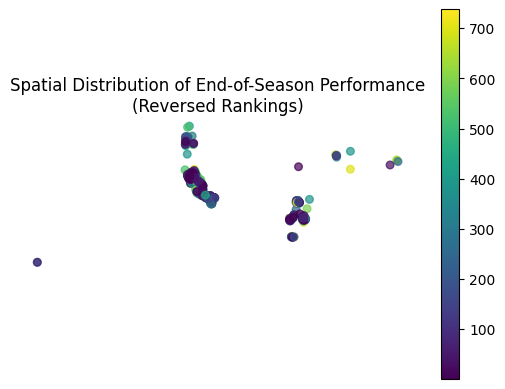

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# GeoDataFrame 생성
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['longitude'], df['latitude'])],
    crs="EPSG:4326"
)

# 간단한 scatter map
plt.figure(figsize=(8,6))
gdf.plot(
    column='Reversed_Ranking',
    cmap='viridis',
    legend=True,
    markersize=30,
    alpha=0.7
)
plt.title("Spatial Distribution of End-of-Season Performance\n(Reversed Rankings)")
plt.axis('off')
plt.show()

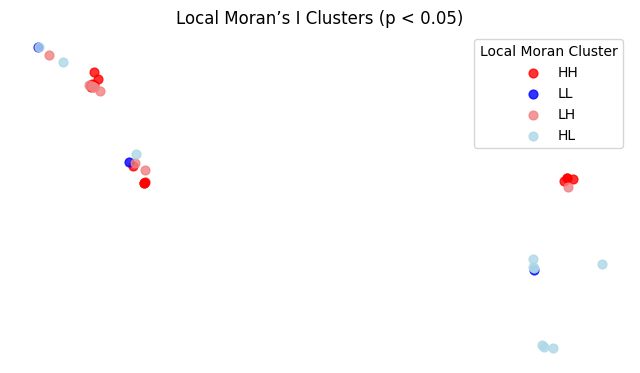

In [ ]:
# Local Moran 결과가 df에 이미 있다고 가정
# df['cluster'] (1=HH, 2=LH, 3=LL, 4=HL)
# df['local_p']

# 유의한 지점만
sig = gdf[gdf['local_p'] < 0.05].copy()

# cluster label 매핑
cluster_labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
sig['cluster_label'] = sig['cluster'].map(cluster_labels)

# 색상 지정
color_map = {
    'HH': 'red',
    'LL': 'blue',
    'LH': 'lightcoral',
    'HL': 'lightblue'
}

plt.figure(figsize=(8,6))
for label, color in color_map.items():
    subset = sig[sig['cluster_label'] == label]
    subset.plot(
        ax=plt.gca(),
        color=color,
        markersize=40,
        label=label,
        alpha=0.8
    )

plt.legend(title='Local Moran Cluster')
plt.title("Local Moran’s I Clusters (p < 0.05)")
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran's I: 0.122
Permutation p-value: 0.001


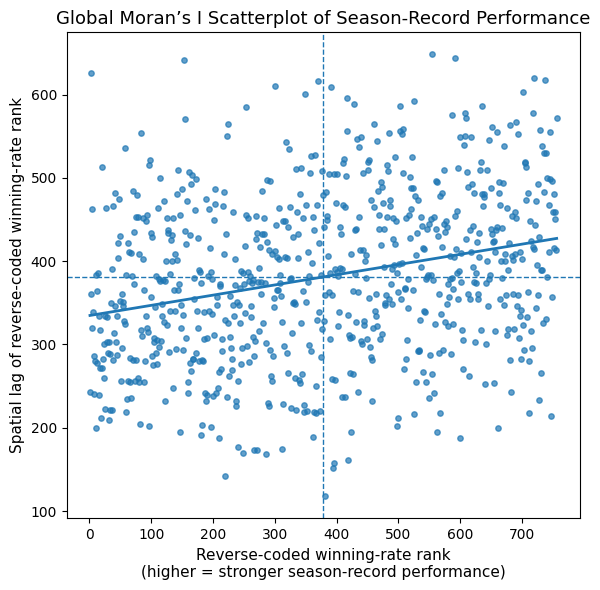

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran

# --------------------------------------------------
# 1. Reversed ranking 생성
# --------------------------------------------------
data['Reversed_Ranking'] = data['ranking'].max() + 1 - data['ranking']

# --------------------------------------------------
# 2. 좌표와 성과 변수
# --------------------------------------------------
coords = data[['longitude', 'latitude']].values
y = data['Reversed_Ranking'].values

# --------------------------------------------------
# 3. Spatial weights (k = 8)
# --------------------------------------------------
w = KNN.from_array(coords, k=8)
w.transform = 'R'  # row-standardization

# --------------------------------------------------
# 4. Moran’s I 계산
# --------------------------------------------------
mi = Moran(y, w, permutations=999)
y_lag = lag_spatial(w, y)

print(f"Moran's I: {mi.I:.3f}")
print(f"Permutation p-value: {mi.p_sim:.3f}")

# --------------------------------------------------
# 5. Moran’s I scatterplot
# --------------------------------------------------
plt.figure(figsize=(6, 6))

# Scatter points
plt.scatter(y, y_lag, s=15, alpha=0.7)

# Regression line (slope = Moran’s I)
b, a = np.polyfit(y, y_lag, 1)
x_vals = np.array([y.min(), y.max()])
plt.plot(x_vals, a + b * x_vals, linewidth=2)

# Mean reference lines (IMPORTANT: not zero)
plt.axvline(y.mean(), linestyle='--', linewidth=1)
plt.axhline(y_lag.mean(), linestyle='--', linewidth=1)

plt.title(
    "Global Moran’s I Scatterplot of Season-Record Performance",
    fontsize=13
)

plt.xlabel(
    "Reverse-coded winning-rate rank\n(higher = stronger season-record performance)",
    fontsize=11
)

plt.ylabel(
    "Spatial lag of reverse-coded winning-rate rank",
    fontsize=11
)
plt.tight_layout()
plt.show()

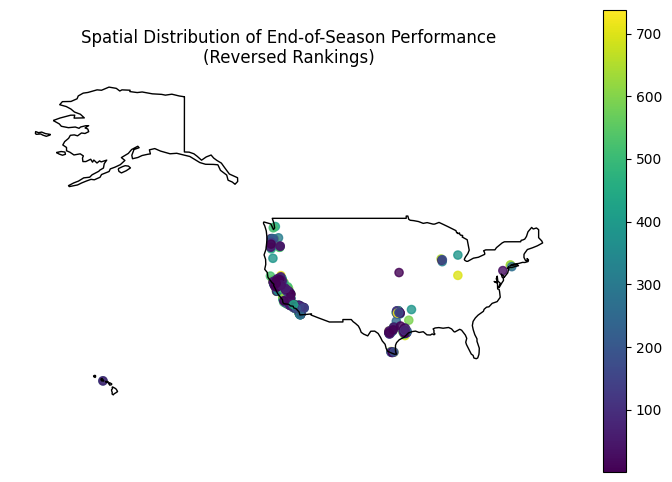

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# ---- GeoDataFrame (네 데이터) ----
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['longitude'], df['latitude'])],
    crs="EPSG:4326"
)

# ---- Natural Earth (미국 경계) URL ----
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

usa = world[world['ADMIN'] == 'United States of America']

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9,6))

usa.boundary.plot(ax=ax, linewidth=1, color='black')

gdf.plot(
    ax=ax,
    column='Reversed_Ranking',
    cmap='viridis',
    legend=True,
    markersize=35,
    alpha=0.8
)

ax.set_title(
    "Spatial Distribution of End-of-Season Performance\n(Reversed Rankings)",
    fontsize=12
)
ax.set_axis_off()

plt.show()

In [ ]:
# 캘리포니아만 필터
ca = df[df['State'] == 'CA'].copy()

coords_ca = list(zip(ca['longitude'], ca['latitude']))
y_ca = ca['Reversed_Ranking'].values

from libpysal.weights import KNN
from esda.moran import Moran

k = 8
w_ca = KNN.from_array(coords_ca, k=k)
w_ca.transform = 'r'

mi_ca = Moran(y_ca, w_ca, permutations=999)

print("California-only Moran’s I")
print("I:", mi_ca.I)
print("z:", mi_ca.z_norm)
print("p (perm):", mi_ca.p_sim)

California-only Moran’s I
I: -0.04044089908994724
z: -1.9726168887941393
p (perm): 0.017


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


National N: 755
California N: 571


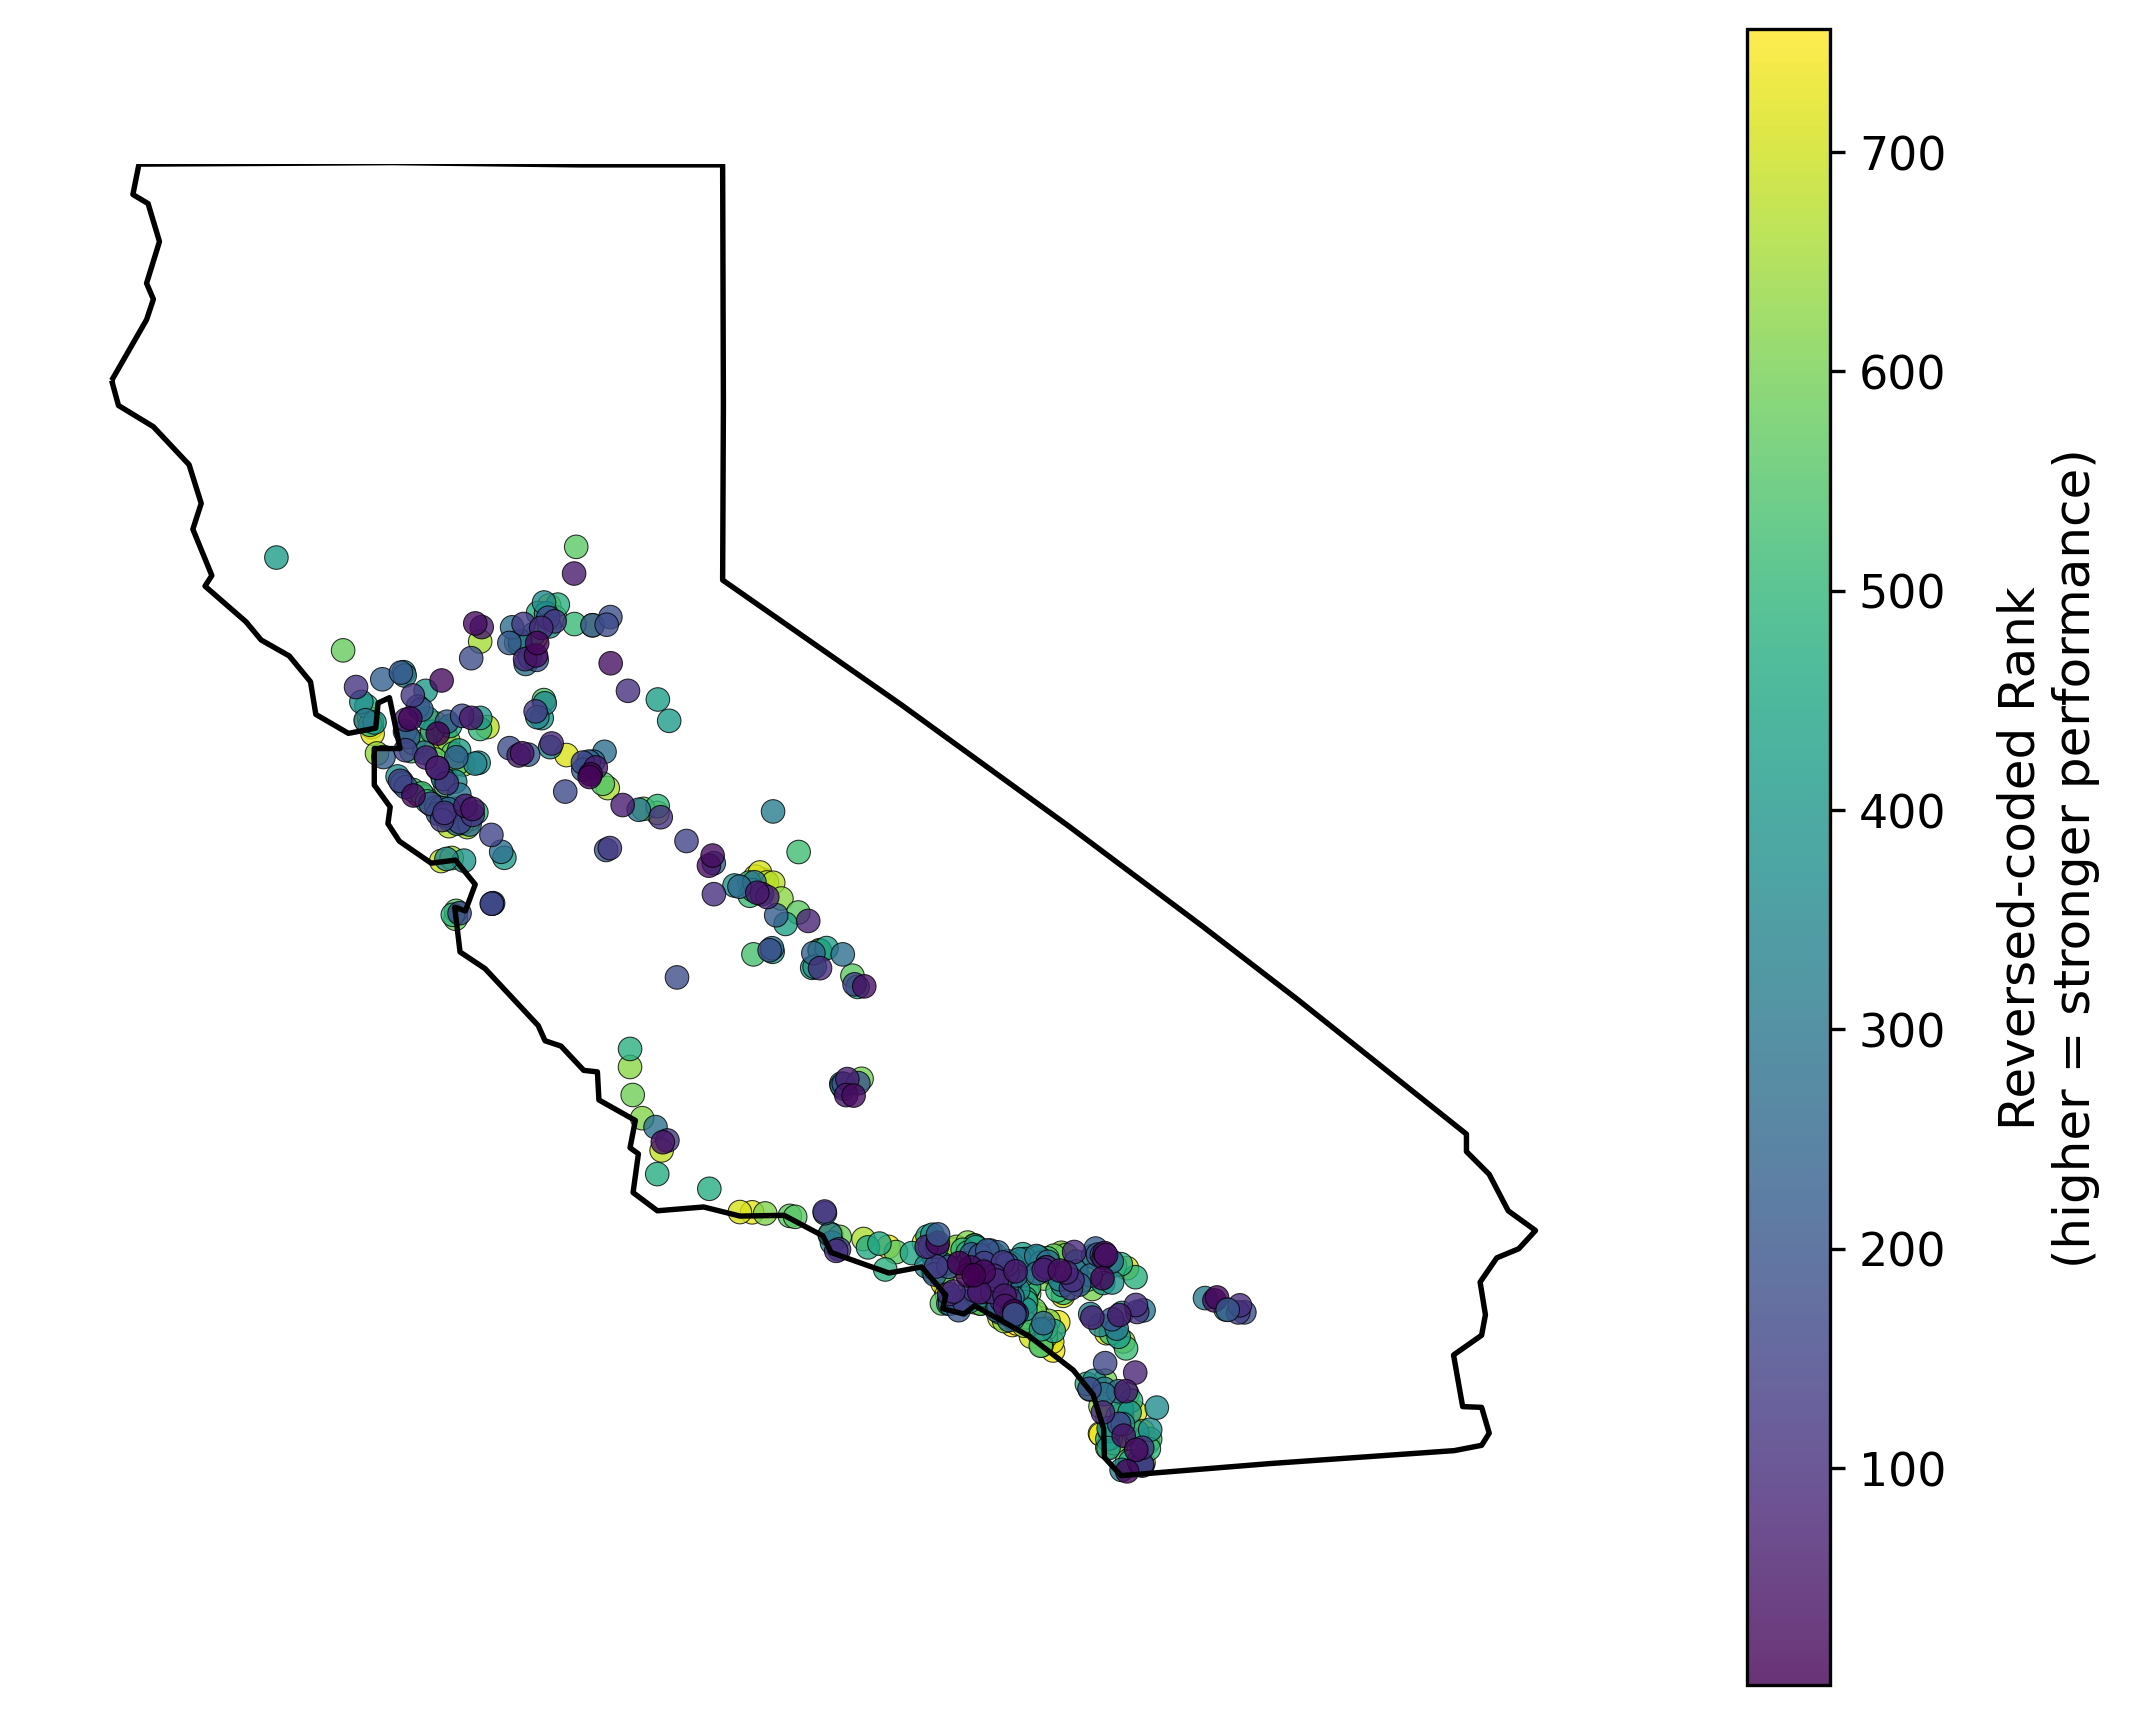

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Global Moran's I: 0.122449
Permutation p-value: 0.001


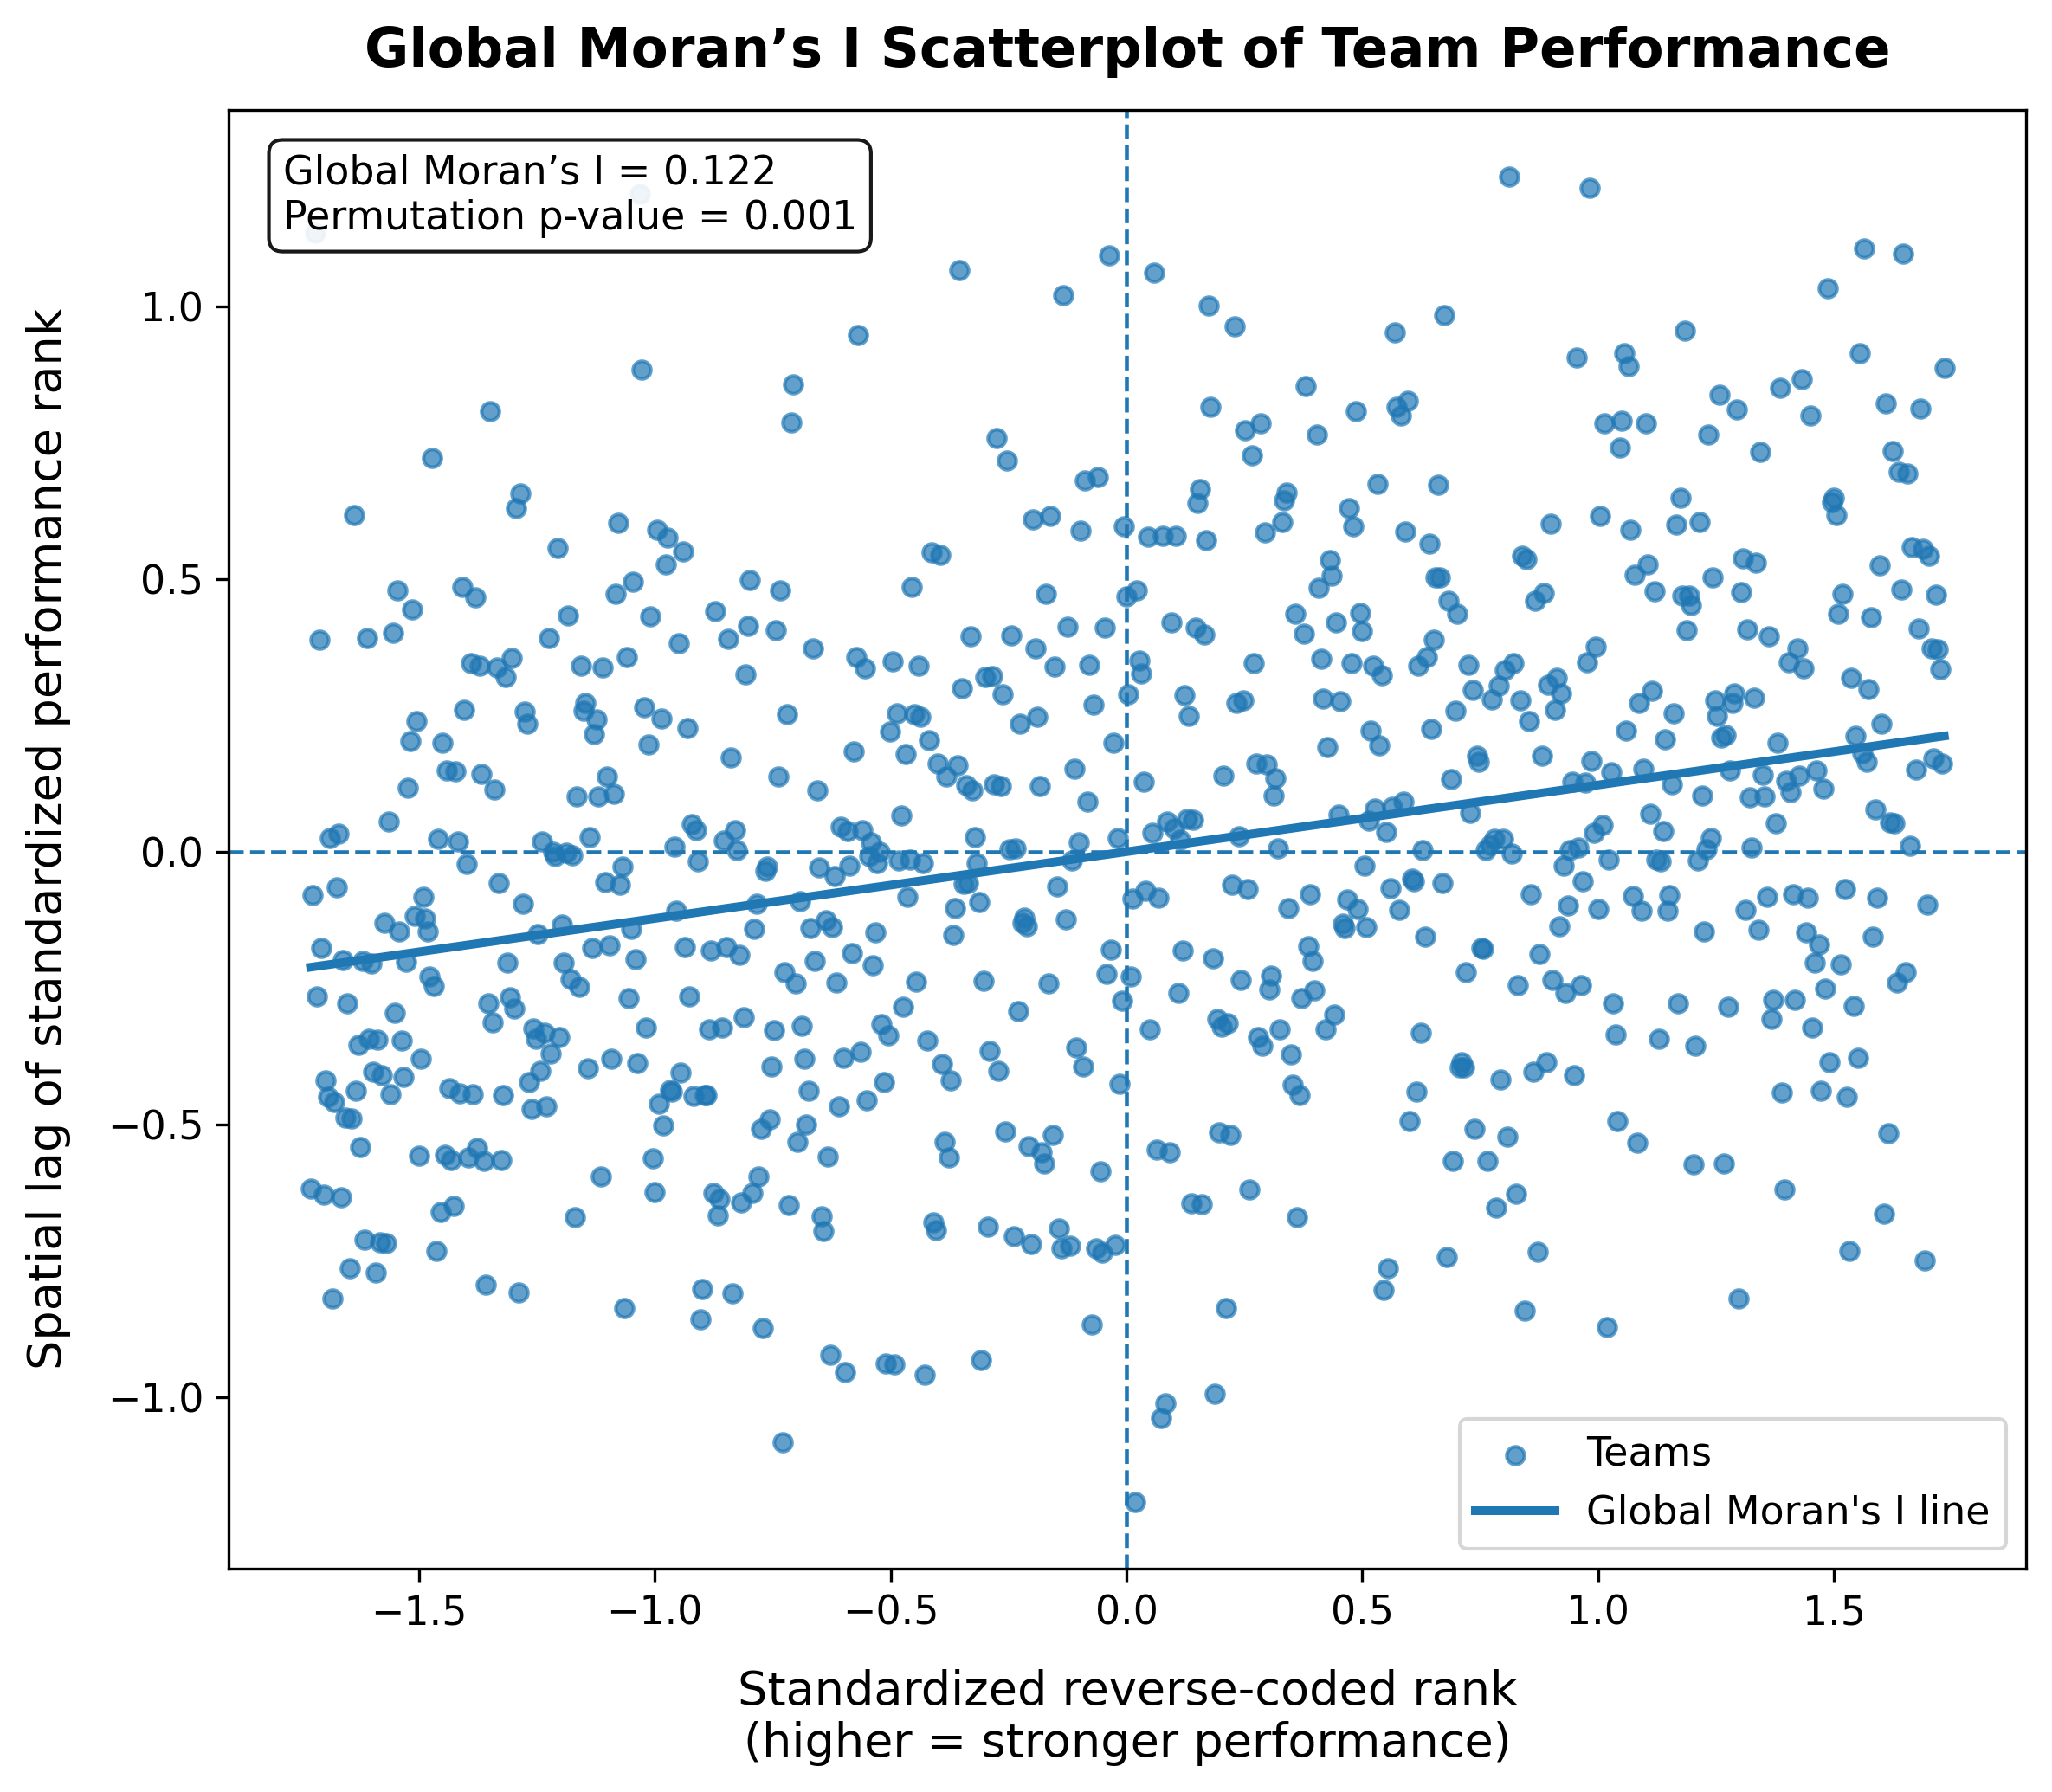

In [ ]:
# ==========================================================
# FINAL FIGURE 1 + FIGURE 2 CODE
# Reviewer Comment 11: identify Figure 2 as GLOBAL
# Reviewer Comment 13: increase font sizes
# ==========================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran


# ----------------------------------------------------------
# 0. Setup
# ----------------------------------------------------------

os.makedirs("figures", exist_ok=True)

# `ranking` is your researcher-defined winning-rate rank.
# Lower rank = stronger performance.
data["ranking"] = pd.to_numeric(data["ranking"], errors="coerce")

# Reverse-code ranking so higher value = stronger performance.
data["Reversed_Ranking"] = (
    data["ranking"].max() + 1 - data["ranking"]
)

outcome_col = "Reversed_Ranking"

# Same valid observations used in the Moran's I analysis
data["longitude"] = pd.to_numeric(data["longitude"], errors="coerce")
data["latitude"] = pd.to_numeric(data["latitude"], errors="coerce")

df = data.dropna(
    subset=["longitude", "latitude", outcome_col]
).copy()

print("National N:", len(df))
print("California N:", len(df[df["State"] == "CA"]))

# Font sizes for reviewer Comment 13
TITLE_FS = 15
AXIS_LABEL_FS = 13
TICK_FS = 11
LEGEND_FS = 11
COLORBAR_LABEL_FS = 12
ANNOTATION_FS = 11


# ==========================================================
# FIGURE 1: California performance map
# ==========================================================

ca_df = df[df["State"] == "CA"].copy()

ca_gdf = gpd.GeoDataFrame(
    ca_df,
    geometry=gpd.points_from_xy(
        ca_df["longitude"],
        ca_df["latitude"]
    ),
    crs="EPSG:4326"
)

# California boundary
states = gpd.read_file(
    "https://raw.githubusercontent.com/"
    "PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

california = states[
    states["name"] == "California"
].to_crs("EPSG:4326")

# Use national score scale for consistent interpretation
score_min = df[outcome_col].min()
score_max = df[outcome_col].max()

fig, ax = plt.subplots(figsize=(7.2, 9.2), dpi=300)

# California outline
california.boundary.plot(
    ax=ax,
    linewidth=1.3,
    color="black"
)

# Teams
sc = ax.scatter(
    ca_gdf.geometry.x,
    ca_gdf.geometry.y,
    c=ca_gdf[outcome_col],
    cmap="viridis",
    vmin=score_min,
    vmax=score_max,
    s=32,
    alpha=0.80,
    edgecolors="black",
    linewidths=0.25
)

ax.set_xlim(-125, -113)
ax.set_ylim(32, 42)
ax.set_aspect("equal")
ax.set_axis_off()

# No map title: manuscript caption serves as figure title.

cbar = fig.colorbar(
    sc,
    ax=ax,
    fraction=0.046,
    pad=0.03
)

cbar.set_label(
    "Reversed-coded Rank\n"
    "(higher = stronger performance)",
    fontsize=COLORBAR_LABEL_FS,
    labelpad=12
)

cbar.ax.tick_params(labelsize=TICK_FS)

plt.tight_layout()

plt.savefig(
    "figures/figure1_california_performance_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# FIGURE 2: Global Moran's I scatterplot
# ==========================================================

plot_df = df.copy()

coords = plot_df[["longitude", "latitude"]].values
y = plot_df[outcome_col].values

k = 8

w = KNN.from_array(coords, k=k)
w.transform = "r"

# Fixed seed for reproducible permutation p-value
np.random.seed(12345)

mi = Moran(y, w, permutations=999)

# Standardized Moran scatterplot values
z = (y - y.mean()) / y.std(ddof=0)
z_lag = lag_spatial(w, z)

print(f"Global Moran's I: {mi.I:.6f}")
print(f"Permutation p-value: {mi.p_sim:.3f}")

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# Scatter points
ax.scatter(
    z,
    z_lag,
    s=24,
    alpha=0.70,
    label="Teams"
)

# Moran's I reference line
x_vals = np.linspace(z.min(), z.max(), 200)

ax.plot(
    x_vals,
    mi.I * x_vals,
    linewidth=2.4,
    label="Global Moran's I line"
)

# Reference lines at standardized mean = 0
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.1
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.1
)

# Reviewer Comment 11: explicitly say GLOBAL
ax.set_title(
    "Global Moran’s I Scatterplot of Team Performance",
    fontsize=TITLE_FS,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Standardized reverse-coded rank\n"
    "(higher = stronger performance)",
    fontsize=AXIS_LABEL_FS,
    labelpad=10
)

ax.set_ylabel(
    "Spatial lag of standardized performance rank",
    fontsize=AXIS_LABEL_FS,
    labelpad=10
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FS
)

ax.legend(
    fontsize=LEGEND_FS,
    loc="best",
    frameon=True
)

ax.text(
    0.03,
    0.97,
    f"Global Moran’s I = {mi.I:.3f}\n"
    f"Permutation p-value = {mi.p_sim:.3f}",
    transform=ax.transAxes,
    va="top",
    fontsize=ANNOTATION_FS,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.90
    )
)

plt.tight_layout()

plt.savefig(
    "figures/figure2_global_morans_i_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# FIGURE 1 + FIGURE 2
# Larger fonts for Reviewer Comment 13
# ==========================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran

# ----------------------------------------------------------
# 0. Shared setup
# ----------------------------------------------------------

os.makedirs("figures", exist_ok=True)

# Your researcher-defined ranking is already stored in `ranking`.
# Reverse-code it so that higher values = stronger performance.
data["Reversed_Ranking"] = (
    data["ranking"].max() + 1 - data["ranking"]
)

outcome_col = "Reversed_Ranking"

# Use the same valid observations as the Moran's I analysis.
df = data.dropna(
    subset=["longitude", "latitude", outcome_col]
).copy()

# Larger journal-ready font sizes
TITLE_FS = 16
AXIS_LABEL_FS = 13
TICK_FS = 11
LEGEND_FS = 11
COLORBAR_LABEL_FS = 12
ANNOTATION_FS = 11

# ==========================================================
# FIGURE 1: California spatial distribution map
# ==========================================================

ca_df = df[df["State"] == "CA"].copy()

ca_gdf = gpd.GeoDataFrame(
    ca_df,
    geometry=gpd.points_from_xy(
        ca_df["longitude"],
        ca_df["latitude"]
    ),
    crs="EPSG:4326"
)

states = gpd.read_file(
    "https://raw.githubusercontent.com/"
    "PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

california = states[states["name"] == "California"].to_crs("EPSG:4326")

# Keep the scale consistent with the national analytic dataset.
score_min = df[outcome_col].min()
score_max = df[outcome_col].max()

fig, ax = plt.subplots(figsize=(7.2, 9.2), dpi=300)

california.boundary.plot(
    ax=ax,
    linewidth=1.3,
    color="black"
)

sc = ax.scatter(
    ca_gdf.geometry.x,
    ca_gdf.geometry.y,
    c=ca_gdf[outcome_col],
    cmap="viridis",
    vmin=score_min,
    vmax=score_max,
    s=32,
    alpha=0.80,
    edgecolors="black",
    linewidths=0.25
)

ax.set_xlim(-125, -113)
ax.set_ylim(32, 42)
ax.set_aspect("equal")
ax.set_axis_off()
)

cbar = fig.colorbar(
    sc,
    ax=ax,
    fraction=0.046,
    pad=0.03
)

cbar.set_label(
    "Reverse-coded winning-rate rank\n"
    "(higher = stronger season-record performance)",
    fontsize=COLORBAR_LABEL_FS,
    labelpad=12
)

cbar.ax.tick_params(labelsize=TICK_FS)

plt.tight_layout()

plt.savefig(
    "figures/figure1_california_performance_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# FIGURE 2: Global Moran's I scatterplot
# ==========================================================

plot_df = df.copy()

coords = plot_df[["longitude", "latitude"]].values
y = plot_df[outcome_col].values

k = 8

w = KNN.from_array(coords, k=k)
w.transform = "r"

np.random.seed(12345)

mi = Moran(y, w, permutations=999)
y_lag = lag_spatial(w, y)

# Regression line for Moran scatterplot
slope, intercept = np.polyfit(y, y_lag, 1)

print(f"Global Moran's I: {mi.I:.6f}")
print(f"Scatterplot slope: {slope:.6f}")
print(f"Permutation p-value: {mi.p_sim:.3f}")

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

ax.scatter(
    y,
    y_lag,
    s=24,
    alpha=0.70,
    label="Teams"
)

x_vals = np.linspace(y.min(), y.max(), 200)

ax.plot(
    x_vals,
    intercept + slope * x_vals,
    linewidth=2.4,
    label="Fitted global Moran's I line"
)

# Mean reference lines
ax.axvline(
    y.mean(),
    linestyle="--",
    linewidth=1.1
)

ax.axhline(
    y_lag.mean(),
    linestyle="--",
    linewidth=1.1
)

# Reviewer Comment 11: explicitly identify this as GLOBAL
ax.set_xlabel(
    "Rank\n"
    "(higher = stronger season-record performance)",
    fontsize=AXIS_LABEL_FS,
    labelpad=10
)

ax.set_ylabel(
    "Spatial lag of rank",
    fontsize=AXIS_LABEL_FS,
    labelpad=10
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FS
)

ax.legend(
    fontsize=LEGEND_FS,
    loc="best",
    frameon=True
)

ax.text(
    0.03,
    0.97,
    f"Global Moran’s I = {mi.I:.3f}\n"
    f"Permutation p-value = {mi.p_sim:.3f}",
    transform=ax.transAxes,
    va="top",
    fontsize=ANNOTATION_FS,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9)
)

plt.tight_layout()

plt.savefig(
    "figures/figure2_global_morans_i_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SyntaxError: unmatched ')' (3725260399.py, line 94)

In [ ]:
import pandas as pd

# --- National statistics ---
table1_national = {
    "Region": "National",
    "N (teams)": len(data),
    "Reversed Ranking (mean)": data["Reversed_Ranking"].mean(),
    "Reversed Ranking (SD)": data["Reversed_Ranking"].std(),
    "Moran's I": -0.05047395248537956,
    "Permutation p-value": 0.003
}

# --- California subset ---
ca = data[data["State"] == "CA"]

table1_ca = {
    "Region": "California",
    "N (teams)": len(ca),
    "Reversed Ranking (mean)": ca["Reversed_Ranking"].mean(),
    "Reversed Ranking (SD)": ca["Reversed_Ranking"].std(),
    "Moran's I": -0.04044089908994724,
    "Permutation p-value": 0.021
}

table1 = pd.DataFrame([table1_national, table1_ca])

# Round for publication
table1 = table1.round(3)

table1

,Region,N (teams),Reversed Ranking (mean),Reversed Ranking (SD),Moran's I,Permutation p-value
0,National,755,378.000,218.065,-0.05,0.003
1,California,571,373.962,212.036,-0.04,0.021


In [ ]:
data["Cluster"].value_counts(dropna=False)

,count
Cluster,
2,310
1,297
0,148


In [ ]:
from esda.moran import Moran_Local

# y: 성과 변수
y = data["Reversed_Ranking"].values

# w: 이미 만든 spatial weights (kNN, k=8)
# 예: w = weights.KNN.from_dataframe(gdf, k=8)

lisa = Moran_Local(y, w)

data["local_I"] = lisa.Is
data["local_p"] = lisa.p_sim
data["quadrant"] = lisa.q

In [ ]:
quad_map = {
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL"
}

data["LISA_Cluster"] = data["quadrant"].map(quad_map)

In [ ]:
table2 = (
    data[data["local_p"] < 0.05]
    .groupby("LISA_Cluster")
    .size()
    .reset_index(name="Number of Teams")
)

cluster_description = {
    "HH": "High-performing teams near high-performing teams",
    "LL": "Low-performing teams near low-performing teams",
    "HL": "High-performing teams near low-performing teams",
    "LH": "Low-performing teams near high-performing teams"
}

table2["Description"] = table2["LISA_Cluster"].map(cluster_description)

table2 = table2[["LISA_Cluster", "Description", "Number of Teams"]]
table2 = table2.rename(columns={"LISA_Cluster": "Cluster Type"})

table2

,Cluster Type,Description,Number of Teams
0,HH,High-performing teams near high-performing teams,3
1,HL,High-performing teams near low-performing teams,16
2,LH,Low-performing teams near high-performing teams,11
3,LL,Low-performing teams near low-performing teams,11


In [ ]:
import pandas as pd

# Local Moran cluster 요약 (유의한 것만)
# Cluster 컬럼에 HH, LL, HL, LH 값이 들어있다고 가정
table2 = (
    data[data["Cluster"].isin(["HH", "LL", "HL", "LH"])]
    .groupby("Cluster")
    .size()
    .reset_index(name="Number of Teams")
)

# 설명 추가 (JEI용)
cluster_description = {
    "HH": "High-performing teams near high-performing teams",
    "LL": "Low-performing teams near low-performing teams",
    "HL": "High-performing teams near low-performing teams",
    "LH": "Low-performing teams near high-performing teams"
}

table2["Description"] = table2["Cluster"].map(cluster_description)

# 컬럼 정리
table2 = table2[["Cluster", "Description", "Number of Teams"]]
table2 = table2.rename(columns={"Cluster": "Cluster Type"})

table2

,Cluster Type,Description,Number of Teams


In [ ]:
import pandas as pd
from geopy.distance import geodesic

# 파일 경로 지정
file_path = '/content/drive/My Drive/Ashton/waterpolo_with_rating_01232025.csv'

# CSV 파일 읽기
data = pd.read_csv(file_path, dtype={'Zip Code': str}, encoding='ISO-8859-1')

# 위도와 경도 값 확인 및 변환
data['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')

# 결측치 제거 (위도와 경도)
data = data.dropna(subset=['latitude', 'longitude'])

# Total Games와 Winning Rate 계산
data['Total Games'] = data['Wins'] + data['Losses'] + data['Draw']
data['Winning_Rate'] = data['Wins'] / data['Total Games']

# 20마일 범위 내 밀도를 계산하는 함수
def calculate_density(df, radius):
    density = []  # 밀도 값을 저장할 리스트
    total_teams = len(df)  # 전체 팀의 수

    for index, row in df.iterrows():
        count = 0  # 현재 팀을 기준으로 20마일 이내 팀 수
        team_location = (row['latitude'], row['longitude'])

        # 다른 팀들과 비교하여 거리 계산
        for _, other_row in df.iterrows():
            if index != other_row.name:  # 자기 자신 제외
                other_team_location = (other_row['latitude'], other_row['longitude'])
                distance = geodesic(team_location, other_team_location).miles
                if distance <= radius:
                    count += 1  # 20마일 이내 팀 수 증가

        # 밀도 리스트에 추가
        density.append(count)

    # DataFrame에 'Density' 열 추가
    df['Density'] = density
    return df

# 20마일 범위 내 밀도 계산
radius = 10  # 반경 20마일
data_with_density = calculate_density(data, radius)

# 선택한 변수 출력 (Total Games와 Public/Private 포함)
print(data_with_density[['ranking', 'Wins', 'Losses', 'Draw', 'Total Games',
                         'strength_of_schedule', 'longitude', 'latitude',
                         'Winning_Rate', 'Density', 'Public/Private']].head())

# CSV 파일로 저장
output_file_path = '/content/drive/My Drive/Ashton/merged_with_density.csv'
data_with_density.to_csv(output_file_path, index=False, encoding='ISO-8859-1')

print(f"CSV 파일로 저장되었습니다: {output_file_path}")

   ranking  Wins  Losses  Draw  Total Games  strength_of_schedule   longitude  \
0        1    29       4     0           33                 34.20 -117.667821   
1        2    33       1     0           34                 49.75 -117.910973   
2        3    23       7     0           30                 33.40 -117.201469   
3        4    19      10     0           29                 32.90 -122.194356   
4        5    32       0     1           33                 17.00  -95.187588   

    latitude  Winning_Rate  Density Public/Private  
0  33.520979      0.878788       13        Private  
1  33.623604      0.970588       22         Public  
2  32.959655      0.766667       14        Private  
3  37.448149      0.655172       13        Private  
4  29.550575      0.969697        8         Public  
CSV 파일로 저장되었습니다: /content/drive/My Drive/Ashton/merged_with_density.csv


In [ ]:
import pandas as pd #alias

# 파일 경로 지정
file_path = '/content/drive/My Drive/Ashton/merged_with_density.csv'

# CSV 파일 읽기
data = pd.read_csv(file_path, dtype={'Zip Code': str}, encoding='ISO-8859-1')

# 데이터 확인
print(data.head())

   ranking                                   name State  Wins  Losses  Draw  \
0        1  JSerra Catholic (San Juan Capistrano)    CA    29       4     0   
1        2         Newport Harbor (Newport Beach)    CA    33       1     0   
2        3         Cathedral Catholic (San Diego)    CA    23       7     0   
3        4           Sacred Heart Prep (Atherton)    CA    19      10     0   
4        5              Clear Creek (League City)    TX    32       0     1   

   strength_of_schedule Public/Private Section/Region  \
0                 34.20        Private       Southern   
1                 49.75         Public       Southern   
2                 33.40        Private      San Diego   
3                 32.90        Private  Central Coast   
4                 17.00         Public          South   

                     Address  ... Girls' Level Girls' Season  \
0  26351 Junipero Serra Road  ...   Varsity/JV        Winter   
1          600 Irvine Avenue  ...   Varsity/JV        

In [ ]:
data['Reversed_Ranking'] = data['ranking'].max() - data['ranking'] + 1

Cluster
0   -0.897783
1    0.001921
2    0.759786
Name: Reversed_Ranking, dtype: float64


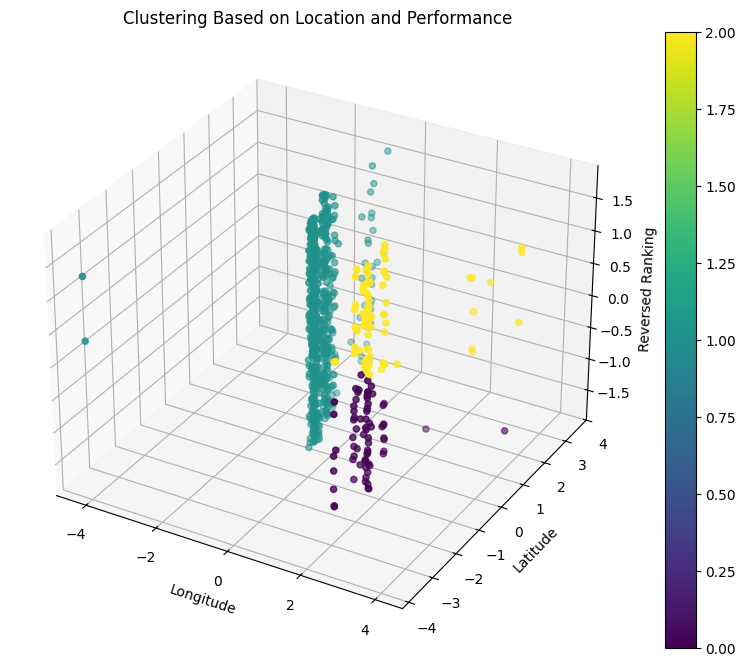

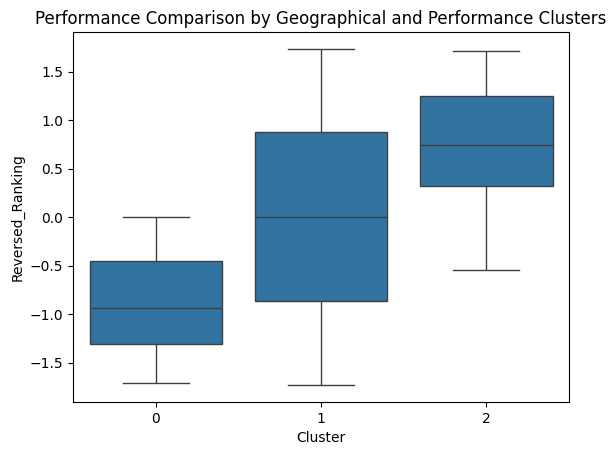

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'data' contains 'latitude', 'longitude', and 'Reversed_Ranking'
# data = pd.read_csv('your_data.csv')  # Load your data here

# Step 1: Preprocess the data (normalize latitude, longitude, and Reversed_Ranking)
scaler = StandardScaler()
data[['latitude', 'longitude', 'Reversed_Ranking']] = scaler.fit_transform(data[['latitude', 'longitude', 'Reversed_Ranking']])

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust the number of clusters as needed
data['Cluster'] = kmeans.fit_predict(data[['latitude', 'longitude', 'Reversed_Ranking']])

# Step 3: Analyze performance by cluster
# Calculate the mean reversed ranking for each cluster
cluster_performance = data.groupby('Cluster')['Reversed_Ranking'].mean()
print(cluster_performance)

# Step 4: Visualize the clusters
# Visualizing the clusters in 3D (latitude, longitude, Reversed_Ranking)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for the clusters
scatter = ax.scatter(data['longitude'], data['latitude'], data['Reversed_Ranking'], c=data['Cluster'], cmap='viridis')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Reversed Ranking')
ax.set_title('Clustering Based on Location and Performance')

# Show the color bar to indicate the clusters
plt.colorbar(scatter)
plt.show()

# Step 5: Performance comparison across clusters
# You can use a boxplot to see the performance distribution (Reversed_Ranking) in each cluster
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Comparison by Geographical and Performance Clusters")
plt.show()

Cluster
0    0.034106
1    0.853006
2   -0.833518
Name: Reversed_Ranking, dtype: float64
지도 파일이 저장되었습니다: /content/drive/My Drive/team_clusters_map.html


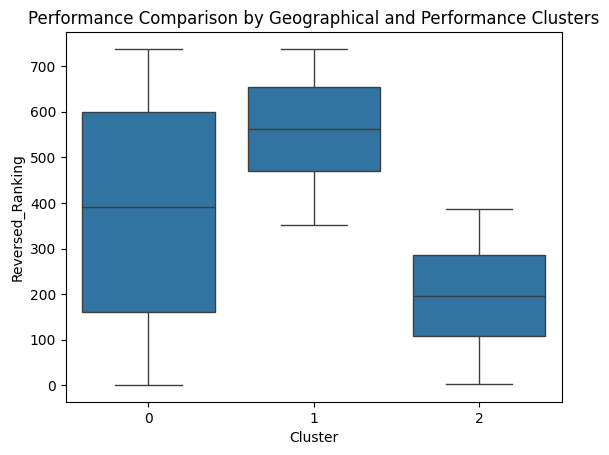

In [ ]:
import pandas as pd
from geopy.distance import geodesic
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import folium
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 경로 지정
file_path = '/content/drive/My Drive/Ashton/waterpolo_with_rating_01232025.csv'

# CSV 파일 읽기
data = pd.read_csv(file_path, dtype={'Zip Code': str}, encoding='ISO-8859-1')

# 위도와 경도 값 확인 및 변환
data['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')

# 결측치 제거 (위도와 경도)
data = data.dropna(subset=['latitude', 'longitude'])

# Total Games와 Winning Rate 계산
data['Total Games'] = data['Wins'] + data['Losses'] + data['Draw']
data['Winning_Rate'] = data['Wins'] / data['Total Games']

# Reversed_Ranking 계산 (예시로 랭킹이 높은 팀은 1위, 낮은 팀은 높은 값)
data['Reversed_Ranking'] = data['Winning_Rate'].rank(ascending=False)

# 20마일 범위 내 밀도 계산하는 함수
def calculate_density(df, radius):
    density = []  # 밀도 값을 저장할 리스트
    total_teams = len(df)  # 전체 팀의 수

    for index, row in df.iterrows():
        count = 0  # 현재 팀을 기준으로 20마일 이내 팀 수
        team_location = (row['latitude'], row['longitude'])

        # 다른 팀들과 비교하여 거리 계산
        for _, other_row in df.iterrows():
            if index != other_row.name:  # 자기 자신 제외
                other_team_location = (other_row['latitude'], other_row['longitude'])
                distance = geodesic(team_location, other_team_location).miles
                if distance <= radius:
                    count += 1  # 20마일 이내 팀 수 증가

        # 밀도 리스트에 추가
        density.append(count)

    # DataFrame에 'Density' 열 추가
    df['Density'] = density
    return df

# 20마일 범위 내 밀도 계산
radius = 10  # 반경 10마일
data_with_density = calculate_density(data, radius)

# 표준화
scaler = StandardScaler()
data[['latitude', 'longitude', 'Reversed_Ranking']] = scaler.fit_transform(data[['latitude', 'longitude', 'Reversed_Ranking']])

# K-Means 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[['latitude', 'longitude', 'Reversed_Ranking']])

# 클러스터링 결과 확인
cluster_performance = data.groupby('Cluster')['Reversed_Ranking'].mean()
print(cluster_performance)

# 역변환: 위도, 경도, Reversed_Ranking 복원
data[['latitude', 'longitude', 'Reversed_Ranking']] = scaler.inverse_transform(data[['latitude', 'longitude', 'Reversed_Ranking']])

# 지도 생성
m = folium.Map(location=[data['latitude'].mean(), data['longitude'].mean()], zoom_start=6)

# 클러스터별 색상으로 지도에 마커 추가
for index, row in data.iterrows():
    cluster = row['Cluster']
    color = 'blue' if cluster == 0 else 'green' if cluster == 1 else 'red'  # Cluster에 따라 색상 지정

    # 각 팀의 위치에 마커 추가
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)

# 지도 저장
output_map_path = '/content/drive/My Drive/team_clusters_map.html'
m.save(output_map_path)
print(f"지도 파일이 저장되었습니다: {output_map_path}")

# 성능 분포를 클러스터별로 박스 플롯으로 시각화
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Comparison by Geographical and Performance Clusters")
plt.show()

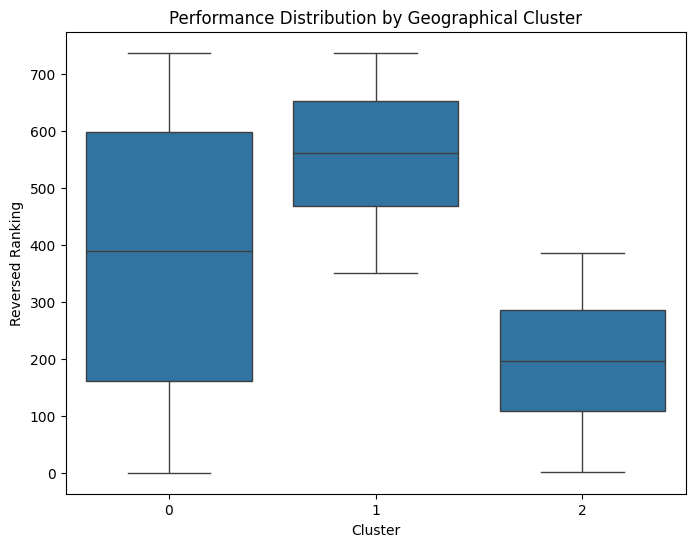

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to visualize the distribution of Reversed_Ranking for each cluster
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Distribution by Geographical Cluster")
plt.xlabel("Cluster")
plt.ylabel("Reversed Ranking")
plt.show()

In [ ]:
# 각 클러스터별 평균 값 계산
cluster_stats = data.groupby('Cluster')[['Total Games', 'Wins', 'Losses', 'Draw', 'Winning_Rate', 'Density', 'strength_of_schedule']].mean()
print(cluster_stats)

         Total Games       Wins     Losses      Draw  Winning_Rate    Density  \
Cluster                                                                         
0          18.013514   9.027027   8.864865  0.121622      0.457220   5.013514   
1          19.121212   5.959596  13.124579  0.037037      0.285717  12.336700   
2          25.764516  16.570968   9.190323  0.003226      0.638807  12.677419   

         strength_of_schedule  
Cluster                        
0                    2.247162  
1                   -0.498923  
2                    5.272290  


In [ ]:
# 원래의 위도와 경도 값을 사용하여 지도 생성
m = folium.Map(location=[data['latitude'].mean(), data['longitude'].mean()], zoom_start=6)

# 각 팀의 위치에 클러스터별로 색상 지정
for index, row in data.iterrows():
    cluster = row['Cluster']
    color = 'blue' if cluster == 0 else 'green' if cluster == 1 else 'red'  # Cluster에 따라 색상 지정

    # 각 팀의 위치에 마커 추가
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)

# 지도 저장
m.save("/content/drive/My Drive/team_clusters_map1.html")

Cluster
0    376.315436
1    357.236641
2    394.584302
Name: Reversed_Ranking, dtype: float64


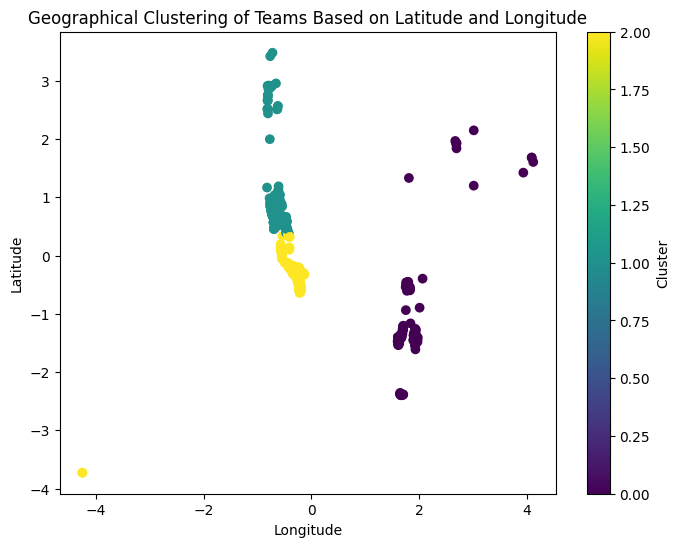

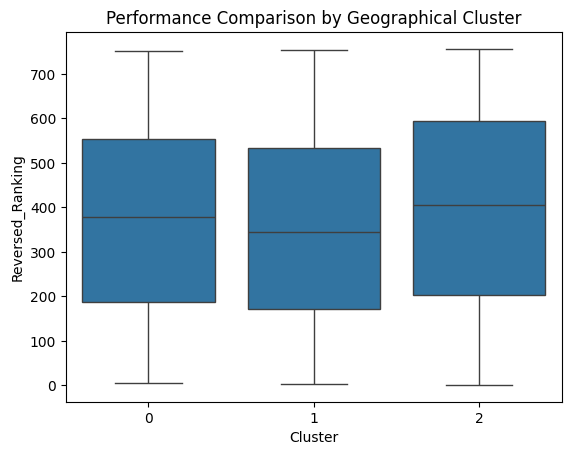

In [ ]:
# cluster analysis
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' contains 'latitude', 'longitude', and performance data (e.g., 'Winning_Rate')
# You may need to modify this according to your actual data

# Step 1: Prepare the data
# Example: data with 'latitude', 'longitude', and 'Winning_Rate'
# 'latitude' and 'longitude' should be numeric values for the team's location
# We are assuming that 'Winning_Rate' is the target performance variable

# Normalize the geographical data (optional but helpful for K-Means)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['latitude', 'longitude']] = scaler.fit_transform(data[['latitude', 'longitude']])

# Step 2: Apply K-Means clustering
# Define the number of clusters (e.g., 3, but you may adjust based on analysis)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[['latitude', 'longitude']])

# Step 3: Analyze performance by cluster
# Group by clusters and calculate the mean Reversed Ranking for each cluster
cluster_performance = data.groupby('Cluster')['Reversed_Ranking'].mean()
print(cluster_performance)

# Step 4: Visualize the clusters
plt.figure(figsize=(8,6))

# Plot the clusters on a scatter plot
plt.scatter(data['longitude'], data['latitude'], c=data['Cluster'], cmap='viridis')
plt.title("Geographical Clustering of Teams Based on Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Cluster')
plt.show()

# Optional: You can analyze other performance metrics in each cluster
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Comparison by Geographical Cluster")
plt.show()

Inertia values (Elbow Method):
Clusters: 1, Inertia: 2265.0000000000005
Clusters: 2, Inertia: 1365.4138892095723
Clusters: 3, Inertia: 1151.8161753735667
Clusters: 4, Inertia: 687.9348021584756
Clusters: 5, Inertia: 545.9012587649756
Clusters: 6, Inertia: 484.4049582876355
Clusters: 7, Inertia: 424.4689089552646
Clusters: 8, Inertia: 389.62958068579013
Clusters: 9, Inertia: 355.27980127429385
Clusters: 10, Inertia: 334.57754759396676

Silhouette Scores:
Clusters: 2, Silhouette Score: 0.4132574272954724
Clusters: 3, Silhouette Score: 0.30768005896097644
Clusters: 4, Silhouette Score: 0.3203145339986992
Clusters: 5, Silhouette Score: 0.3135633699934007
Clusters: 6, Silhouette Score: 0.2736416113986121
Clusters: 7, Silhouette Score: 0.2759006382635122
Clusters: 8, Silhouette Score: 0.2658314078175962
Clusters: 9, Silhouette Score: 0.2585784826429694
Clusters: 10, Silhouette Score: 0.261383203700424


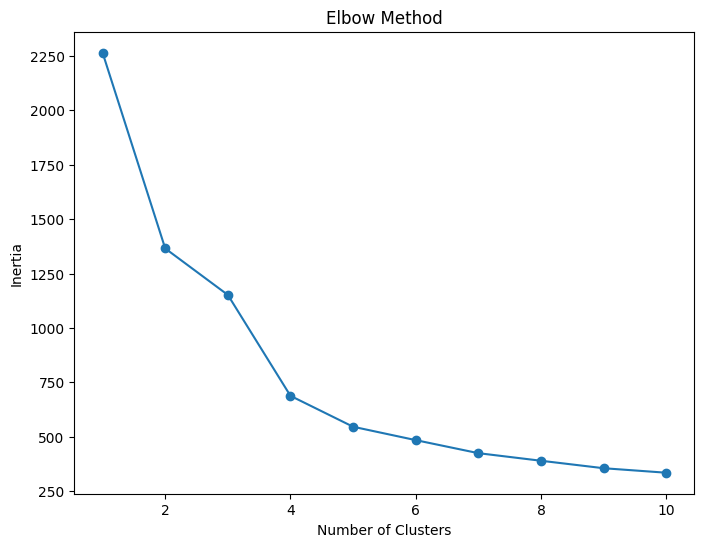

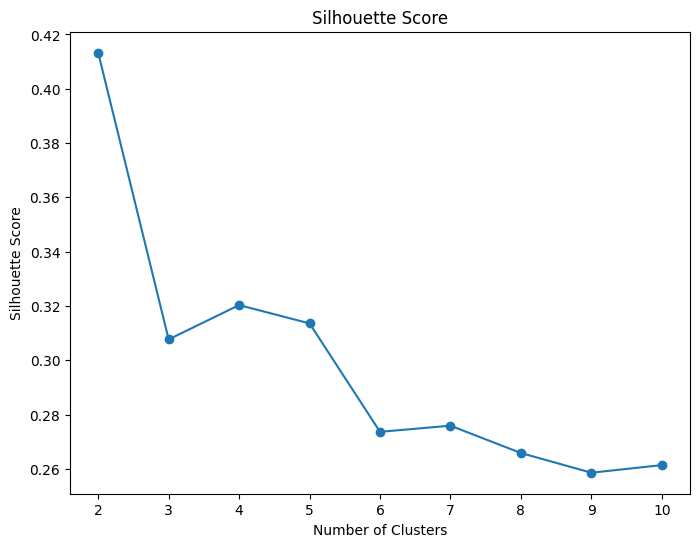


Cluster Performance (Average Reversed_Ranking):
Cluster
0    517.665904
1    186.113208
Name: Reversed_Ranking, dtype: float64


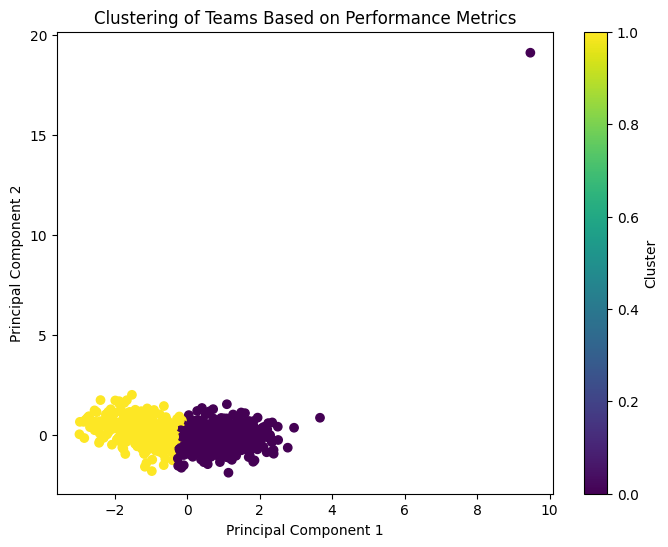

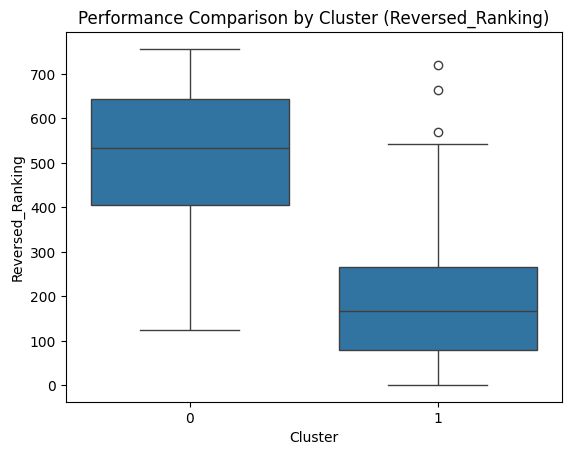

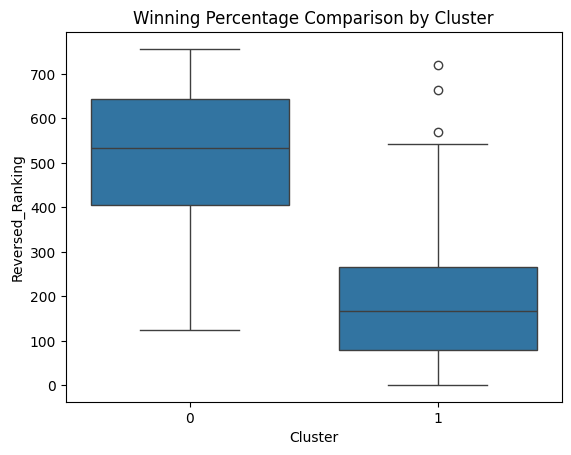

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Step 1: Prepare the data
# Assuming 'data' contains performance data including 'Reversed_Ranking', 'Total_Games', and other performance metrics
# Include other features like 'Wins', 'Losses', 'Draw', 'Strength_of_Schedule', 'Winning_Percentage'

# Normalize performance and location data
scaler = StandardScaler()
features = ['strength_of_schedule', 'Winning_Rate', 'Total Games']
data[features] = scaler.fit_transform(data[features])

# Step 2: Optimize the number of clusters
# Elbow Method and Silhouette Score
inertia = []
sil_score = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data[features])
    inertia.append(kmeans.inertia_)
    if k > 1:
        sil_score.append(silhouette_score(data[features], kmeans.labels_))

# Elbow Method: Print inertia values
print("Inertia values (Elbow Method):")
for k, value in enumerate(inertia, 1):
    print(f"Clusters: {k}, Inertia: {value}")

# Silhouette Score: Print silhouette scores
print("\nSilhouette Scores:")
for k, score in enumerate(sil_score, 2):
    print(f"Clusters: {k}, Silhouette Score: {score}")

# Plot Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_score, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Step 3: Apply K-Means clustering with optimal clusters
optimal_k = 2  # Choose the optimal number of clusters based on the elbow or silhouette method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[features])

# Step 4: Analyze performance by cluster
cluster_performance = data.groupby('Cluster')['Reversed_Ranking'].mean()
print("\nCluster Performance (Average Reversed_Ranking):")
print(cluster_performance)

# Optional: Visualize clusters using PCA for dimensionality reduction (2D)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data[features])

# Visualize clusters in 2D
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=data['Cluster'], cmap='viridis')
plt.title("Clustering of Teams Based on Performance Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Step 5: Analyze other performance metrics in each cluster
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Comparison by Cluster (Reversed_Ranking)")
plt.show()

# Optional: Visualize Winning_Percentage by Cluster (replace 'Reversed_Ranking' with 'Winning_Percentage' if needed)
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Winning Percentage Comparison by Cluster")
plt.show()

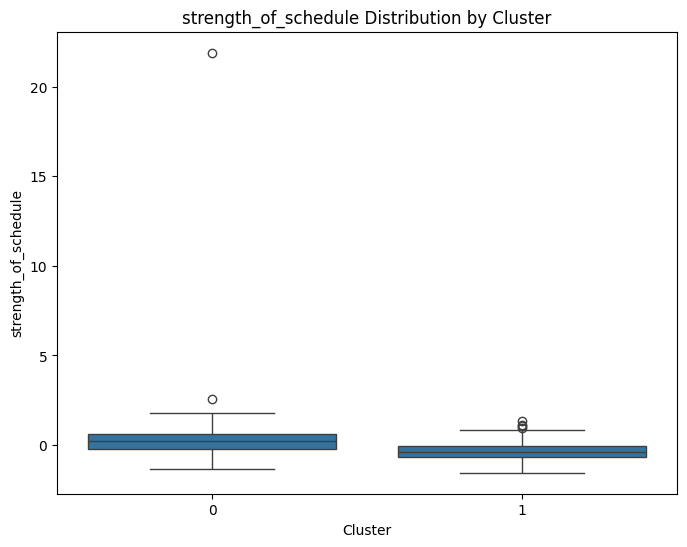

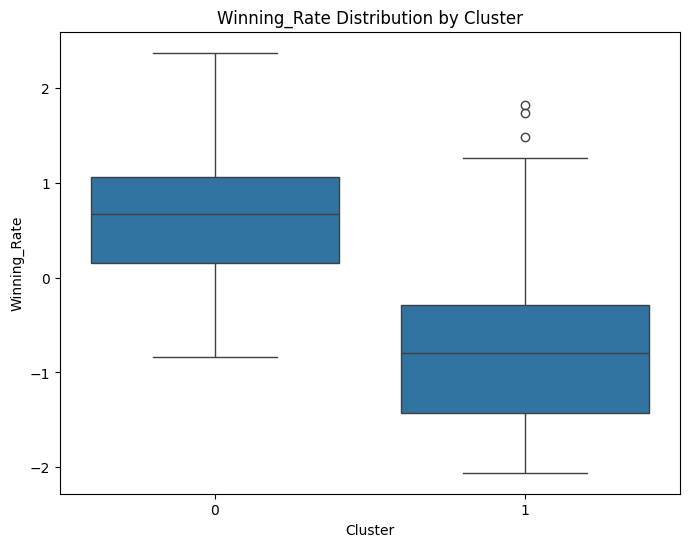

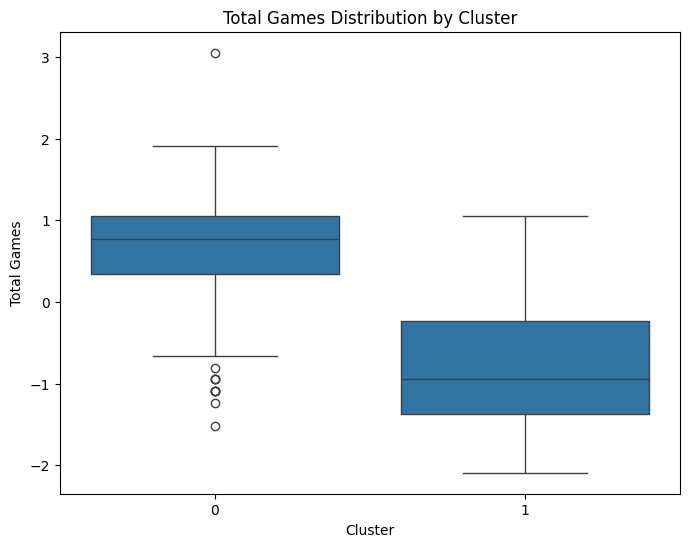

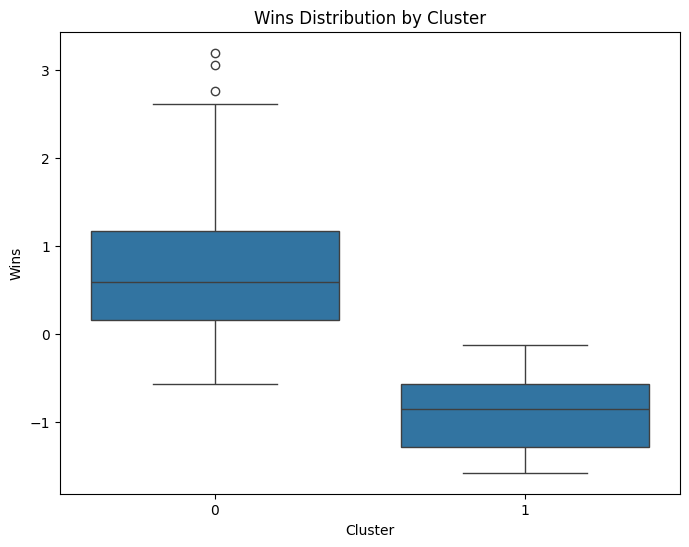

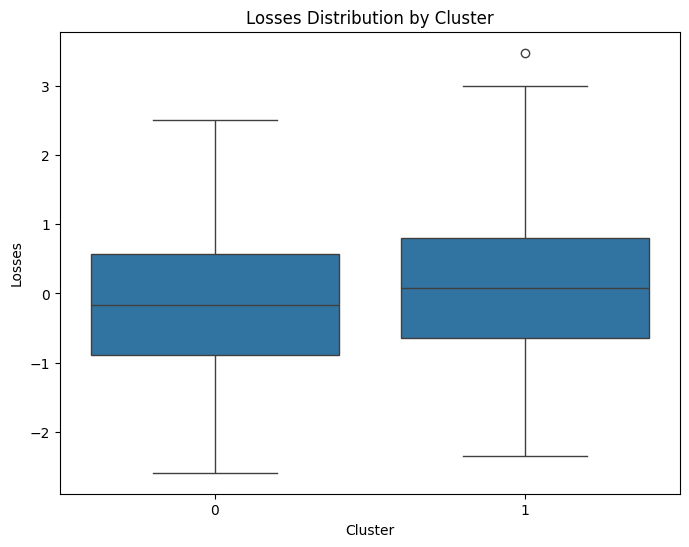

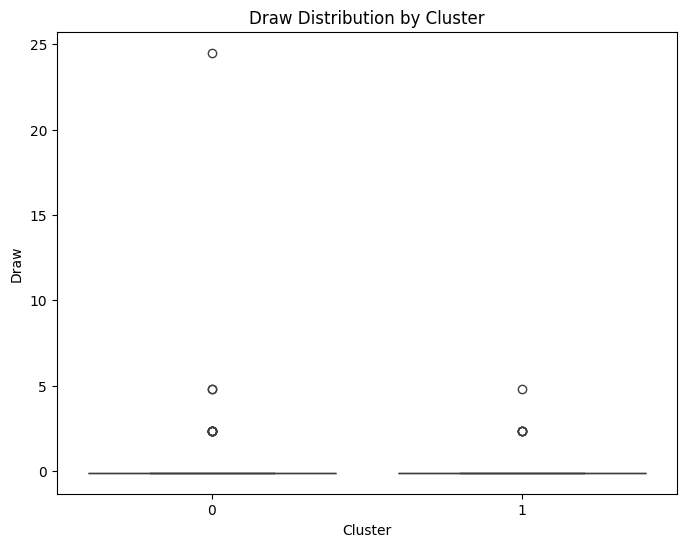


Descriptive Statistics by Cluster:
        strength_of_schedule                                          \
                       count      mean       std       min       25%   
Cluster                                                                
0                      416.0  0.277041  1.208802 -1.306895 -0.213723   
1                      339.0 -0.339967  0.478817 -1.541185 -0.664488   

                                       Winning_Rate            ...    Losses  \
              50%       75%        max        count      mean  ...       75%   
Cluster                                                        ...             
0        0.218148  0.614929  21.895352        416.0  0.651497  ...  0.565179   
1       -0.383772 -0.046373   1.343710        339.0 -0.799478  ...  0.808181   

                    Draw                                                 \
              max  count      mean       std      min      25%      50%   
Cluster                                             

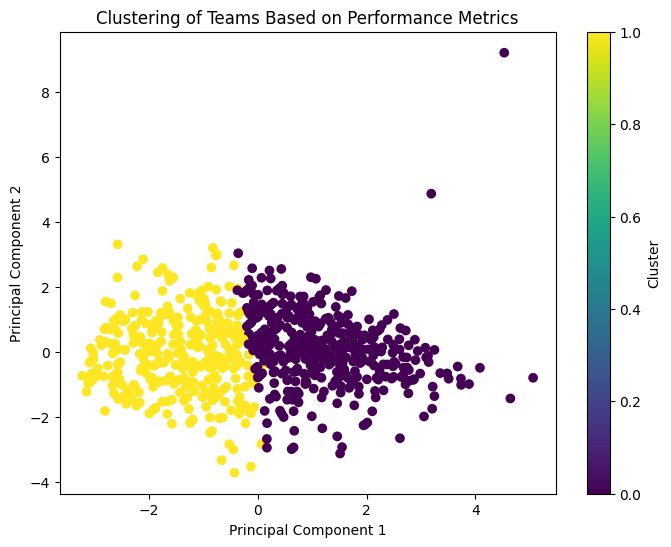

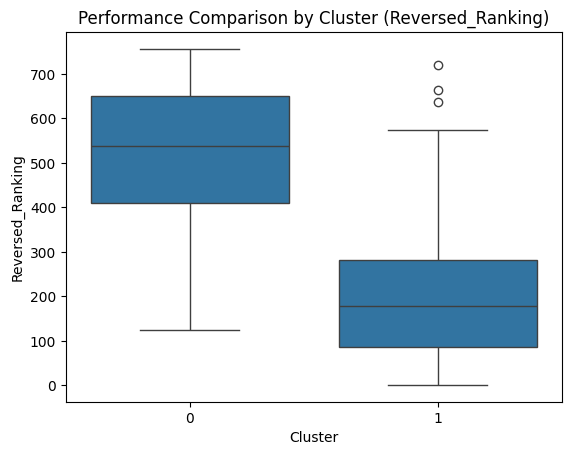

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats

# Step 1: Prepare the data (assuming 'data' is already loaded with relevant features)
# Normalize performance and location data
scaler = StandardScaler()
features = ['strength_of_schedule', 'Winning_Rate', 'Total Games', 'Wins', 'Losses', 'Draw']
data[features] = scaler.fit_transform(data[features])

# Step 2: Apply K-Means clustering with optimal clusters (k=2)
optimal_k = 2  # Based on previous analysis (e.g., Elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[features])

# Step 3: Explore how features differ between clusters
# Box plots to visualize the distribution of features across clusters
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cluster', y=feature, data=data)
    plt.title(f'{feature} Distribution by Cluster')
    plt.show()

# Step 4: Descriptive statistics by cluster
cluster_summary = data.groupby('Cluster')[features].describe()
print("\nDescriptive Statistics by Cluster:")
print(cluster_summary)

# Step 5: Statistical tests to determine feature differences
# Perform an independent t-test (or ANOVA for more than two groups) to test for significant differences
for feature in features:
    cluster_0 = data[data['Cluster'] == 0][feature]
    cluster_1 = data[data['Cluster'] == 1][feature]

    # Independent t-test to check if there are significant differences between clusters
    t_stat, p_value = stats.ttest_ind(cluster_0, cluster_1)

    # Print the results of the t-test
    print(f"\nT-test for {feature}:")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Significant difference detected for {feature}")
    else:
        print(f"No significant difference for {feature}")

# Optional: Visualize clusters using PCA for dimensionality reduction (2D)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data[features])

# Visualize clusters in 2D
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=data['Cluster'], cmap='viridis')
plt.title("Clustering of Teams Based on Performance Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Step 6: Visualize performance metrics comparison (e.g., Reversed_Ranking) across clusters
sns.boxplot(x='Cluster', y='Reversed_Ranking', data=data)
plt.title("Performance Comparison by Cluster (Reversed_Ranking)")
plt.show()

In [ ]:
import folium

# Assuming 'data' has columns 'latitude', 'longitude', and 'Cluster'
# Create a map centered around an average latitude and longitude
map_center = [data['latitude'].mean(), data['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Plot each team's location with a different color based on cluster
for index, row in data.iterrows():
    cluster = row['Cluster']
    color = 'blue' if cluster == 0 else 'red'  # Blue for Cluster 0, Red for Cluster 1

    # Add a marker for each team
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)

# Save map as an HTML file
m.save("team_clusters_map.html")

   ranking   latitude   longitude  Density  Winning_Rate  DBSCAN_Cluster  \
0        1  33.520979 -117.667821       13      0.878788              -1   
1        2  33.623604 -117.910973       22      0.970588              -1   
2        3  32.959655 -117.201469       14      0.766667              -1   
3        4  37.448149 -122.194356       13      0.655172              -1   
4        5  29.550575  -95.187588        8      0.969697              -1   

   KMeans_Cluster  
0               1  
1               1  
2               1  
3               1  
4               0  


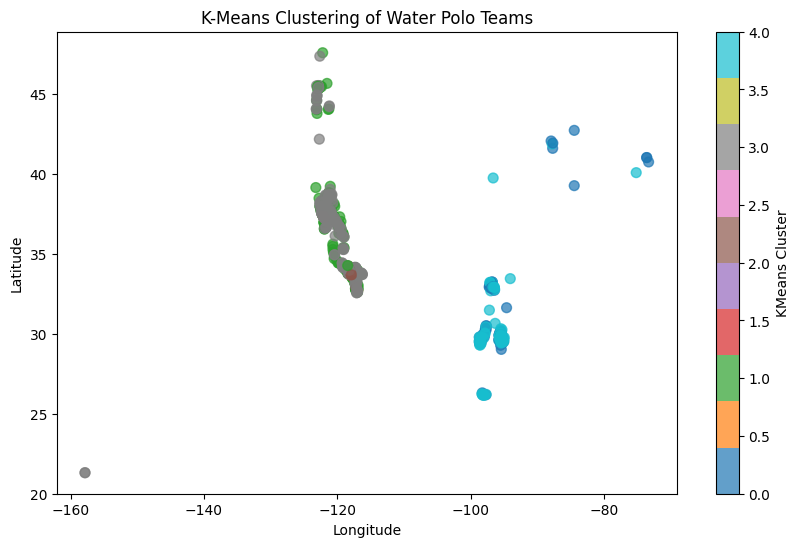

클러스터링 결과가 포함된 CSV 파일로 저장되었습니다: /content/drive/My Drive/Ashton/clustered_with_density.csv


In [ ]:
import pandas as pd
from geopy.distance import geodesic
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 파일 경로 지정
file_path = '/content/drive/My Drive/Ashton/waterpolo_with_rating_01232025.csv'

# CSV 파일 읽기
data = pd.read_csv(file_path, dtype={'Zip Code': str}, encoding='ISO-8859-1')

# 위도와 경도 값 확인 및 변환
data['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')

# 결측치 제거 (위도와 경도)
data = data.dropna(subset=['latitude', 'longitude'])

# Total Games와 Winning Rate 계산
data['Total Games'] = data['Wins'] + data['Losses'] + data['Draw']
data['Winning_Rate'] = data['Wins'] / data['Total Games']

# 20마일 범위 내 밀도를 계산하는 함수
def calculate_density(df, radius):
    density = []  # 밀도 값을 저장할 리스트
    for index, row in df.iterrows():
        count = 0  # 현재 팀을 기준으로 20마일 이내 팀 수
        team_location = (row['latitude'], row['longitude'])

        # 다른 팀들과 비교하여 거리 계산
        for _, other_row in df.iterrows():
            if index != other_row.name:  # 자기 자신 제외
                other_team_location = (other_row['latitude'], other_row['longitude'])
                distance = geodesic(team_location, other_team_location).miles
                if distance <= radius:
                    count += 1  # 20마일 이내 팀 수 증가

        # 밀도 리스트에 추가
        density.append(count)

    # DataFrame에 'Density' 열 추가
    df['Density'] = density
    return df

# 20마일 범위 내 밀도 계산
radius = 10  # 반경 20마일
data = calculate_density(data, radius)

# 클러스터링에 사용할 변수 선택
features = ['latitude', 'longitude', 'Density', 'Winning_Rate', 'Total Games', 'strength_of_schedule']
X = data[features]

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN 클러스터링
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# K-Means 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터 결과 출력
print(data[['ranking', 'latitude', 'longitude', 'Density', 'Winning_Rate',
            'DBSCAN_Cluster', 'KMeans_Cluster']].head())

# 클러스터링 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(data['longitude'], data['latitude'], c=data['KMeans_Cluster'], cmap='tab10', s=50, alpha=0.7)
plt.colorbar(label='KMeans Cluster')
plt.title('K-Means Clustering of Water Polo Teams')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# CSV 파일로 저장
output_file_path = '/content/drive/My Drive/Ashton/clustered_with_density.csv'
data.to_csv(output_file_path, index=False, encoding='ISO-8859-1')

print(f"클러스터링 결과가 포함된 CSV 파일로 저장되었습니다: {output_file_path}")

In [ ]:
pip install pysal

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 k

In [ ]:
import geopandas as gpd
from pysal.explore.esda.getisord import G_Local

# GeoDataFrame 생성
geo_df = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data['Longitude'], data['Latitude'])
)

# 지역 가중치 행렬 생성
from pysal.lib import weights
w = weights.KNN.from_dataframe(geo_df, k=5)

# Hotspot 분석 (Winning Rate)
g = G_Local(geo_df['Winning Rate'], w)
geo_df['Gi*'] = g.Zs

# 핫스팟 결과 확인
print(geo_df[['Winning Rate', 'Gi*']].head())

2.5
2.5
2.5


/usr/local/lib/python3.11/dist-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


ImportError: cannot import name 'Local_Spatial_Pearson' from 'esda.lee' (/usr/local/lib/python3.11/dist-packages/esda/lee.py)

In [ ]:
pip install --upgrade pysal

In [ ]:
pip install pysal==2.4.0

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.7 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached tobler-0.12.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached spvcm-0.3.0-py3-none-any.whl
  Using cached spreg-1.8.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached spopt-0.6.1-py3-none-any.whl.metadata (10 kB)
  Using cached splot-1.1.7-py3-none-any.whl.metadata (8.9 kB)
  Using cached spaghetti-1.7.6-py3-none-any.whl.meta

In [ ]:
pip install --upgrade libpysal esda

In [ ]:
import geopandas as gpd
from pysal.explore.esda.getisord import G_Local

# GeoDataFrame 생성
geo_df = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data['longitude'], data['latitude'])
)

# 지역 가중치 행렬 생성
from pysal.lib import weights
w = weights.KNN.from_dataframe(geo_df, k=5)

# Hotspot 분석 (Winning Rate)
g = G_Local(geo_df['Reversed_Ranking'], w)
geo_df['Gi*'] = g.Zs

# 핫스팟 결과 확인
print(geo_df[['Reversed_Ranking', 'Gi*']].head())

ImportError: cannot import name 'Local_Spatial_Pearson' from 'esda.lee' (/usr/local/lib/python3.11/dist-packages/esda/lee.py)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save the map in Google Drive
m.save("/content/drive/My Drive/team_clusters_map.html")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant to the independent variables matrix
X = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private', 'Total Games', 'avg_distance_to_strong_teams', 'strong_teams_within_radius']]
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF results
print(vif_data)

KeyError: "['avg_distance_to_strong_teams', 'strong_teams_within_radius'] not in index"

In [ ]:
# Calculate the correlation table for the variables in the dataset
correlation_matrix = data[['strength_of_schedule', 'Winning_Rate', 'Density', 'Public/Private', 'Total Games', 'avg_distance_to_strong_teams', 'strong_teams_within_radius']].corr()

# Print the correlation table
print(correlation_matrix)

                              strength_of_schedule  Winning_Rate   Density  \
strength_of_schedule                      1.000000      0.172154  0.002979   
Winning_Rate                              0.172154      1.000000  0.025788   
Density                                   0.002979      0.025788  1.000000   
Public/Private                            0.115182      0.072720  0.054837   
Total Games                               0.343707      0.553651  0.119647   
avg_distance_to_strong_teams             -0.008949     -0.030361 -0.421640   
strong_teams_within_radius                0.033894      0.011371  0.553794   

                              Public/Private  Total Games  \
strength_of_schedule                0.115182     0.343707   
Winning_Rate                        0.072720     0.553651   
Density                             0.054837     0.119647   
Public/Private                      1.000000     0.038342   
Total Games                         0.038342     1.000000   
avg_dista

In [ ]:

# Define X and y for the OLS model
X = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private', 'Total Games', 'avg_distance_to_strong_teams']]  # Include relevant predictors
X = sm.add_constant(X)  # Add constant term to the model
y = data['Reversed_Ranking']  # Use the reversed ranking as the dependent variable

# Fit the OLS model
model4 = sm.OLS(y, X).fit()

# Print the summary of the model
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:       Reversed_Ranking   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     464.3
Date:                Tue, 28 Jan 2025   Prob (F-statistic):          1.24e-226
Time:                        05:00:29   Log-Likelihood:                -4603.9
No. Observations:                 755   AIC:                             9220.
Df Residuals:                     749   BIC:                             9248.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant to the independent variables matrix
X = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private', 'Total Games', 'avg_distance_to_strong_teams']]
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF results
print(vif_data)

                       Variable       VIF
0                         const  6.251752
1          strength_of_schedule  1.158106
2                  Winning_Rate  1.476562
3                Public/Private  1.018753
4                   Total Games  1.737098
5  avg_distance_to_strong_teams  1.094235


In [ ]:
# 상호작용 항목 추가: 예시로 Winning_Rate와 strength_of_schedule의 상호작용을 추가
data['Winning_Rate_X_strength_of_schedule'] = data['Winning_Rate'] * data['strength_of_schedule']

# 모델 정의 (상호작용 항목 포함)
X_interaction = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private', 'Total Games', 'avg_distance_to_strong_teams', 'Winning_Rate_X_strength_of_schedule']]
X_interaction = sm.add_constant(X_interaction)  # 상수 항 추가

# 모델 피팅
model_interaction = sm.OLS(y, X_interaction).fit()

# 상호작용 항목 포함한 모델 결과 요약
print("상호작용 항목 포함한 모델 결과:")
print(model_interaction.summary())

상호작용 항목 포함한 모델 결과:
                            OLS Regression Results                            
Dep. Variable:       Reversed_Ranking   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     474.8
Date:                Tue, 28 Jan 2025   Prob (F-statistic):          3.75e-251
Time:                        05:00:29   Log-Likelihood:                -4543.7
No. Observations:                 755   AIC:                             9101.
Df Residuals:                     748   BIC:                             9134.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 상호작용 항목 포함된 모델에 사용될 변수들 선택
X_interaction_vif = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private', 'Total Games',
                           'avg_distance_to_strong_teams', 'Winning_Rate_X_strength_of_schedule']]

# 상수 항 추가
X_interaction_vif = sm.add_constant(X_interaction_vif)

# VIF 계산
vif_data = pd.DataFrame()
vif_data['Variable'] = X_interaction_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_interaction_vif.values, i) for i in range(X_interaction_vif.shape[1])]

# 결과 출력
print("VIF 결과:")
print(vif_data)

VIF 결과:
                              Variable       VIF
0                                const  6.279057
1                 strength_of_schedule  1.494168
2                         Winning_Rate  1.504907
3                       Public/Private  1.039009
4                          Total Games  1.841358
5         avg_distance_to_strong_teams  1.094427
6  Winning_Rate_X_strength_of_schedule  1.312859


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 상호작용 항목 추가 (Total Games와 Public/Private의 상호작용)
data['Total_Games_X_Public_Private'] = data['Total Games'] * data['Public/Private']

# 모델 정의 (새로운 상호작용 항목 포함)
X_improved = data[['strength_of_schedule', 'Winning_Rate', 'Public/Private',
                   'Total Games', 'avg_distance_to_strong_teams',
                   'Total_Games_X_Public_Private']]
X_improved = sm.add_constant(X_improved)  # 상수 항 추가

# 모델 피팅
model_improved = sm.OLS(y, X_improved).fit()

# 개선된 모델 결과 요약 출력
print("개선된 모델 결과:")
print(model_improved.summary())

# VIF 계산
vif_data_improved = pd.DataFrame()
vif_data_improved['Variable'] = X_improved.columns
vif_data_improved['VIF'] = [variance_inflation_factor(X_improved.values, i) for i in range(X_improved.shape[1])]
print("\n개선된 모델 VIF 결과:")
print(vif_data_improved)

개선된 모델 결과:
                            OLS Regression Results                            
Dep. Variable:       Reversed_Ranking   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     386.4
Date:                Tue, 28 Jan 2025   Prob (F-statistic):          2.77e-225
Time:                        05:00:29   Log-Likelihood:                -4603.9
No. Observations:                 755   AIC:                             9222.
Df Residuals:                     748   BIC:                             9254.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const

In [ ]:
# 모델 정의 (Public/Private 변수 제거 후 상호작용 항목만 포함)
X_improved_reduced = data[['strength_of_schedule', 'Winning_Rate',
                           'Total Games', 'avg_distance_to_strong_teams',
                           'Total_Games_X_Public_Private']]
X_improved_reduced = sm.add_constant(X_improved_reduced)  # 상수 항 추가

# 모델 피팅
model_improved_reduced = sm.OLS(y, X_improved_reduced).fit()

# 개선된 모델 결과 요약 출력
print("개선된 모델 (Public/Private 제거) 결과:")
print(model_improved_reduced.summary())

# VIF 계산
vif_data_improved_reduced = pd.DataFrame()
vif_data_improved_reduced['Variable'] = X_improved_reduced.columns
vif_data_improved_reduced['VIF'] = [variance_inflation_factor(X_improved_reduced.values, i) for i in range(X_improved_reduced.shape[1])]
print("\n개선된 모델 VIF 결과 (Public/Private 제거):")
print(vif_data_improved_reduced)

개선된 모델 (Public/Private 제거) 결과:
                            OLS Regression Results                            
Dep. Variable:       Reversed_Ranking   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     452.1
Date:                Tue, 28 Jan 2025   Prob (F-statistic):          2.26e-223
Time:                        05:00:29   Log-Likelihood:                -4611.5
No. Observations:                 755   AIC:                             9235.
Df Residuals:                     749   BIC:                             9263.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:
print(data.columns)

Index(['strength_of_schedule', 'Winning_Rate', 'Density', 'Public/Private',
       'Reversed_Ranking', 'Total Games', 'avg_distance_to_strong_teams',
       'strong_teams_within_radius', 'Winning_Rate_X_strength_of_schedule',
       'Total_Games_X_Public_Private'],
      dtype='object')


In [ ]:
!pip install geopy

In [ ]:
# Group by state and count the number of teams
state_counts = data['State'].value_counts()

# Display the counts
print(state_counts)

State
CA    590
TX    141
OR     34
IL      4
WA      4
CT      2
HI      2
NY      1
PA      1
OH      1
MI      1
Name: count, dtype: int64


In [ ]:
import folium

# 데이터에서 NaN 값이 있는 행 삭제
data_cleaned = data.dropna(subset=['latitude', 'longitude'])

# 지도 중심을 설정 (미국 중심)
map_center = [37.0902, -95.7129]  # 미국의 중심 (위도, 경도)
map = folium.Map(location=map_center, zoom_start=4)

# 고등학교 위치 데이터를 포함하는 데이터프레임이 'data_cleaned'라고 가정
for index, row in data_cleaned.iterrows():
    # 각 고등학교의 위도와 경도 추출
    latitude = row['latitude']
    longitude = row['longitude']

    # 학교 이름을 포함하는 열 이름 수정 (예: 'SchoolName' -> 실제 열 이름으로 수정)
    school_name = row['name']  # 'SchoolName'을 실제 열 이름에 맞게 수정

    # 위도, 경도에 마커 추가
    folium.Marker([latitude, longitude], popup=school_name).add_to(map)

# 지도 HTML로 저장
map.save('/content/merged_waterpolo_map.html')

# Jupyter 노트북에서 직접 지도 보기
map

In [ ]:
pip install selenium pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.7/481.7 kB 30.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim

# Initialize geolocator
geolocator = Nominatim(user_agent="geoapi_exercise")

# Function to get latitude and longitude from Address, City, and State
def get_lat_lon(row):
    address = f"{row['Address']}, {row['City']}, {row['State']}"
    try:
        location = geolocator.geocode(address)
        if location:
            return pd.Series([address, location.latitude, location.longitude], index=['Full Address', 'Latitude', 'Longitude'])
        else:
            return pd.Series([address, None, None], index=['Full Address', 'Latitude', 'Longitude'])
    except Exception as e:
        return pd.Series([address, None, None], index=['Full Address', 'Latitude', 'Longitude'])

# Apply the function to each row in your DataFrame
data[['Full Address', 'Latitude', 'Longitude']] = data.apply(get_lat_lon, axis=1)

# Save the address, latitude, and longitude to an Excel file
data[['Full Address', 'Latitude', 'Longitude']].to_excel("output_lat_lon_with_address.xlsx", index=False)

print("Latitude, Longitude, and Address saved to Excel.")

Latitude, Longitude, and Address saved to Excel.


In [ ]:
import os
print(os.getcwd())  # This will print the current working directory

/content


In [ ]:
data[['Full Address', 'Latitude', 'Longitude']].to_excel("/content/drive/My Drive/output_lat_lon_with_address.xlsx", index=False)

In [ ]:
!apt-get update # Update the package list
!apt install -y chromium-chromedriver # Install the chromium-chromedriver package
!cp /usr/lib/chromium-browser/chromedriver /usr/bin # Move the chromedriver to the path

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,172 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,616 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-s

In [ ]:
chrome_driver_path = '/usr/bin/chromedriver'  # For Google Colab

# Or, if running locally:
# chrome_driver_path = '/path/to/your/chromedriver'  # Local machine path

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# 데이터 불러오기
# (이미 데이터프레임이 data로 로딩되어 있다고 가정)

# Winning Rate 기준 median split
median_wr = data['Winning_Rate'].median()
data['WR_Group'] = data['Winning_Rate'].apply(lambda x: 'Low_WR' if x < median_wr else 'High_WR')

# Low_WR 그룹에서 strength_of_schedule이 ranking에 미치는 영향 분석 (핵심 분석)
low_wr_model = smf.ols('ranking ~ strength_of_schedule', data=data[data['WR_Group'] == 'Low_WR']).fit()

# 결과 출력
print("H5 검증 – Low_WR 그룹에서 strength_of_schedule이 ranking에 미치는 영향:")
print(low_wr_model.summary())

NameError: name 'data' is not defined

In [ ]:
!pip install requests beautifulsoup4 lxml pandas selenium webdriver-manager

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0


In [ ]:
# waterpolo_scraper_colab.py (Colab 버전)

import os, re, csv, time, uuid
from urllib.parse import urljoin
from datetime import datetime

import requests
from bs4 import BeautifulSoup
import pandas as pd

# =========================
# 설정
# =========================
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; ResearchForAcademicUse/1.0; +mailto:your.email@institution.edu)"
}
RATE_LIMIT_SEC = 1.5
TIMEOUT = 30

# 랭킹 페이지 → 팀 링크 수집용 (CSS 구조 맞게 수정)
TEAM_LINK_SELECTOR = "a"  # TODO: 실제 페이지 맞게 수정

# 팀 스케줄 페이지 → 경기 결과 수집용 (CSS 구조 맞게 수정)
SCHEDULE_ROW_SELECTOR = "div.schedule-row"
DATE_SELECTOR         = ".date"
OPPONENT_SELECTOR     = ".opponent"
SCORE_SELECTOR        = ".score"
VENUE_SELECTOR        = ".venue"

TOURNAMENT_KEYWORDS = ["tournament", "playoff", "championship"]

# =========================
# 유틸 함수
# =========================
def sleep():
    time.sleep(RATE_LIMIT_SEC)

def soup_get(url):
    sleep()
    r = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
    r.raise_for_status()
    return BeautifulSoup(r.text, "lxml")

def clean_text(x):
    if not x: return ""
    return re.sub(r"\s+", " ", x).strip()

def normalize_team_id(name: str) -> str:
    nid = re.sub(r"[^a-z0-9]+", "_", name.lower())
    return nid.strip("_")[:64] if nid else f"team_{uuid.uuid4().hex[:8]}"

def parse_score(text):
    if not text: return None, None
    m = re.search(r"(\d+)\s*[-:]\s*(\d+)", text)
    if not m: return None, None
    return int(m.group(1)), int(m.group(2))

def infer_home_away(venue_text, this_team_id, opp_team_id):
    v = (venue_text or "").lower()
    if v.startswith("home"):
        return this_team_id, opp_team_id, "home"
    elif v.startswith("away"):
        return opp_team_id, this_team_id, "away"
    else:
        return this_team_id, opp_team_id, "neutral"

def is_tournament(row_text):
    return int(any(k in (row_text or "").lower() for k in TOURNAMENT_KEYWORDS))

def label_result_and_margin(home_score, away_score):
    try:
        hs, as_ = int(home_score), int(away_score)
    except:
        return None, None
    if hs > as_:
        res = "home_win"
    elif hs < as_:
        res = "away_win"
    else:
        res = "tie"
    return res, abs(hs - as_)

# =========================
# 팀별 경기 결과 수집
# =========================
def scrape_team_schedule(team_name, team_url, season):
    team_id = normalize_team_id(team_name if team_name else team_url)
    soup = soup_get(team_url)

    matches = []
    rows = soup.select(SCHEDULE_ROW_SELECTOR)
    if not rows:
        print(f"[WARN] 일정 없음: {team_name}")
        return team_id, matches

    for row in rows:
        try:
            date = clean_text(row.select_one(DATE_SELECTOR).get_text()) if row.select_one(DATE_SELECTOR) else ""
            opp = clean_text(row.select_one(OPPONENT_SELECTOR).get_text()) if row.select_one(OPPONENT_SELECTOR) else ""
            score_text = clean_text(row.select_one(SCORE_SELECTOR).get_text()) if row.select_one(SCORE_SELECTOR) else ""
            venue_text = clean_text(row.select_one(VENUE_SELECTOR).get_text()) if row.select_one(VENUE_SELECTOR) else ""

            home_score, away_score = parse_score(score_text)
            if not opp: continue

            opp_team_id = normalize_team_id(opp)
            home_id, away_id, venue_norm = infer_home_away(venue_text, team_id, opp_team_id)
            t_flag = is_tournament(row.get_text())

            # 날짜 ISO 변환 시도
            date_iso = date
            for fmt in ("%Y-%m-%d", "%m/%d/%Y", "%b %d, %Y"):
                try:
                    date_iso = datetime.strptime(date, fmt).strftime("%Y-%m-%d")
                    break
                except: pass

            result, margin = label_result_and_margin(home_score, away_score)

            game = {
                "game_id": uuid.uuid4().hex[:12],
                "season": season,
                "date": date_iso,
                "home_team_id": home_id,
                "away_team_id": away_id,
                "home_score": home_score,
                "away_score": away_score,
                "venue": venue_norm,
                "tournament_flag": t_flag,
                "forfeit_flag": 0,
                "result": result,
                "margin": margin,
                "source_team_url": team_url
            }
            matches.append(game)
        except Exception as e:
            print(f"[ROW-ERR] {team_name}: {e}")
            continue
    return team_id, matches

# =========================
# 실행 함수
# =========================
def run_colab_scraper(season="2024-2025", teams_csv="teams_seed.csv"):
    matches_all, teams_seen = [], {}
    with open(teams_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            team_name, team_url = row.get("team_name", ""), row.get("team_url", "")
            if not team_url: continue
            team_id, games = scrape_team_schedule(team_name, team_url, season)
            teams_seen[team_id] = {"team_id": team_id, "team_name": team_name, "team_url": team_url}
            matches_all.extend(games)

    os.makedirs("output", exist_ok=True)
    matches_path = os.path.join("output", "matches.csv")
    teams_path   = os.path.join("output", "teams_seen.csv")

    pd.DataFrame(matches_all).to_csv(matches_path, index=False)
    pd.DataFrame(list(teams_seen.values())).to_csv(teams_path, index=False)

    print(f"[OK] 저장 완료: {matches_path} ({len(matches_all)} 경기), {teams_path} ({len(teams_seen)} 팀)")
    return matches_path, teams_path